# Comprehensive Multinomial Error Analysis
##### Brain Connectivity Classification: 232 Regions Full Connectivity Model

## Setup and Data Loading

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import json
from pathlib import Path
import warnings
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats

warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
sns.set_context('notebook', font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
import pandas as pd
import json
from pathlib import Path
import warnings
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats

warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
sns.set_context('notebook', font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully")

Libraries imported successfully


In [4]:
# Set up paths
PROJECT_ROOT = Path('/home/sjoon/projects/brain_connectivity_classifier')
RESULTS_DIR = PROJECT_ROOT / 'data' / 'results'
ANALYSIS_OUTPUT_DIR = PROJECT_ROOT / 'data' / 'error_analysis' / 'multinomial'
ANALYSIS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Create visualization output directory
VIZ_OUTPUT_DIR = ANALYSIS_OUTPUT_DIR / 'visualizations'
VIZ_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Results Directory: {RESULTS_DIR}")
print(f"Analysis Output: {ANALYSIS_OUTPUT_DIR}")
print(f"Visualization Output: {VIZ_OUTPUT_DIR}")

Results Directory: /home/sjoon/projects/brain_connectivity_classifier/data/results
Analysis Output: /home/sjoon/projects/brain_connectivity_classifier/data/error_analysis/multinomial
Visualization Output: /home/sjoon/projects/brain_connectivity_classifier/data/error_analysis/multinomial/visualizations


In [5]:
# Load helper functions
def load_json(filepath):
    """Load JSON file safely"""
    with open(filepath, 'r') as f:
        return json.load(f)

def load_npy(filepath):
    """Load numpy file safely"""
    return np.load(filepath, allow_pickle=True)

def load_csv(filepath):
    """Load CSV file safely"""
    return pd.read_csv(filepath)

print("Helper functions loaded")

Helper functions loaded


In [6]:
# Directory Setup
full_multi_dir = RESULTS_DIR / 'full_connectivity_analysis' / 'multinomial'
LH_multi_dir = RESULTS_DIR / 'hemisphere_analysis' / 'left_hemisphere' / 'multinomial'
RH_multi_dir = RESULTS_DIR / 'hemisphere_analysis' / 'right_hemisphere' / 'multinomial'

full_task_dir = RESULTS_DIR / 'full_connectivity_analysis' / 'task_testing'
LH_task_dir = RESULTS_DIR / 'hemisphere_analysis' / 'left_hemisphere' / 'task_testing_multinomial'
RH_task_dir = RESULTS_DIR / 'hemisphere_analysis' / 'right_hemisphere' / 'task_testing_multinomial'

def load_bundle(m_dir, t_dir, is_cv=True):
    """Helper to load standard file patterns from directories."""
    res = [
        load_json(m_dir / 'overall_metrics.json'), load_json(m_dir / 'fold_metrics.json'),
        load_csv(m_dir / 'network_metrics.csv'), load_csv(m_dir / 'per_region_metrics.csv'),
        load_npy(m_dir / 'confusion_matrix.npy'), load_npy(m_dir / 'cv_predictions.npy'),
        load_npy(m_dir / 'cv_probabilities.npy'), load_npy(m_dir / 'cv_true_labels.npy'),
        load_npy(m_dir / 'cv_fold_indices.npy'), load_json(t_dir / 'task_testing_summary.json'),
        load_csv(t_dir / 'task_network_metrics.csv'), load_csv(t_dir / 'task_per_region_metrics.csv'),
        load_npy(t_dir / 'task_confusion_matrix.npy'), load_npy(t_dir / 'task_predictions.npy'),
        load_npy(t_dir / 'task_probabilities.npy'), load_npy(t_dir / 'task_true_labels.npy')
    ]
    return res

# --- FULL CONNECTIVITY ---
overall_metrics_full, fold_metrics_full, network_metrics_cv_full, per_region_metrics_cv_full, \
confusion_matrix_cv_full, cv_predictions_full, cv_probabilities_full, cv_true_labels_full, \
cv_fold_indices_full, task_summary_full, network_metrics_task_full, per_region_metrics_task_full, \
confusion_matrix_task_full, task_predictions_full, task_probabilities_full, task_true_labels_full = load_bundle(full_multi_dir, full_task_dir)

region_info_full = load_csv(full_multi_dir / 'region_info.csv')

# --- LEFT HEMISPHERE ---
overall_metrics_lh, fold_metrics_lh, network_metrics_cv_lh, per_region_metrics_cv_lh, \
confusion_matrix_cv_lh, cv_predictions_lh, cv_probabilities_lh, cv_true_labels_lh, \
cv_fold_indices_lh, task_summary_lh, network_metrics_task_lh, per_region_metrics_task_lh, \
confusion_matrix_task_lh, task_predictions_lh, task_probabilities_lh, task_true_labels_lh = load_bundle(LH_multi_dir, LH_task_dir)

region_info_lh = region_info_full[region_info_full['hemisphere'] == 'left'].copy().assign(region_idx=lambda x: range(len(x)))

# --- RIGHT HEMISPHERE ---
overall_metrics_rh, fold_metrics_rh, network_metrics_cv_rh, per_region_metrics_cv_rh, \
confusion_matrix_cv_rh, cv_predictions_rh, cv_probabilities_rh, cv_true_labels_rh, \
cv_fold_indices_rh, task_summary_rh, network_metrics_task_rh, per_region_metrics_task_rh, \
confusion_matrix_task_rh, task_predictions_rh, task_probabilities_rh, task_true_labels_rh = load_bundle(RH_multi_dir, RH_task_dir)

region_info_rh = region_info_full[region_info_full['hemisphere'] == 'right'].copy().assign(region_idx=lambda x: range(len(x)))

# --- COMPARISON ---
print(f"\n{'='*80}\nCOMPREHENSIVE MODEL COMPARISON\n{'='*80}")

models = [
    ('Full (232)', overall_metrics_full, task_summary_full, region_info_full, cv_predictions_full, task_predictions_full, confusion_matrix_cv_full),
    ('Left (116)', overall_metrics_lh, task_summary_lh, region_info_lh, cv_predictions_lh, task_predictions_lh, confusion_matrix_cv_lh),
    ('Right (116)', overall_metrics_rh, task_summary_rh, region_info_rh, cv_predictions_rh, task_predictions_rh, confusion_matrix_cv_rh)
]

comparison_df = pd.DataFrame([{
    'Model': m[0],
    'CV_Accuracy': f"{m[1]['accuracy']:.4f}",
    'Rest_Train_Acc': f"{m[2]['rest_train_accuracy']:.4f}",
    'Task_Accuracy': f"{m[2]['task_test_accuracy']:.4f}",
    'Accuracy_Drop': f"{m[2]['accuracy_drop']:.4f}",
    'N_Regions': len(m[3]),
    'N_Samples_CV': len(m[4]),
    'N_Samples_Task': len(m[5]),
    'CM_Shape': f"{m[6].shape[0]}×{m[6].shape[1]}"
} for m in models])

print(f"\n{comparison_df.to_string(index=False)}")


COMPREHENSIVE MODEL COMPARISON

      Model CV_Accuracy Rest_Train_Acc Task_Accuracy Accuracy_Drop  N_Regions  N_Samples_CV  N_Samples_Task CM_Shape
 Full (232)      0.9241         0.9902        0.8924        0.0978        232         51968           46400  232×232
 Left (116)      0.9182         0.9773        0.8693        0.1080        116         25984           23200  116×116
Right (116)      0.9136         0.9774        0.8631        0.1143        116         25984           23200  116×116


N17 Network Distribution

In [8]:
# ============================================================================
# NETWORK DISTRIBUTION COMPARISON TABLE
# ============================================================================
print(f"\n{'='*80}\nTABLE: NETWORK DISTRIBUTION COMPARISON\n{'='*80}")

all_networks = sorted(region_info_full['network'].unique())

# Aggregate counts into a single DataFrame using the index
network_comparison_df = pd.DataFrame(index=all_networks)
network_comparison_df['Network'] = all_networks
network_comparison_df['Full_Model'] = region_info_full['network'].value_counts()
network_comparison_df['Left_Hemi'] = region_info_lh['network'].value_counts()
network_comparison_df['Right_Hemi'] = region_info_rh['network'].value_counts()
network_comparison_df = network_comparison_df.fillna(0).reset_index(drop=True)

# Vectorized calculations
network_comparison_df['L+R'] = network_comparison_df['Left_Hemi'] + network_comparison_df['Right_Hemi']
network_comparison_df['Match?'] = network_comparison_df['Full_Model'] == network_comparison_df['L+R']
network_comparison_df['Symmetric?'] = network_comparison_df['Left_Hemi'] == network_comparison_df['Right_Hemi']

total_full = network_comparison_df['Full_Model'].sum()
network_comparison_df['% of Total'] = (network_comparison_df['Full_Model'] / total_full * 100).round(1)

print("\n" + network_comparison_df.to_string(index=False))

# ============================================================================
# SUMMARY STATISTICS TABLE
# ============================================================================
print(f"\n{'='*80}\nSUMMARY STATISTICS\n{'='*80}")

summary_data = {
    'Metric': ['Total Regions', 'Number of Networks', 'Symmetric Networks (L=R)', 'Asymmetric Networks', 'Verification (Full = L+R)'],
    'Value': [
        f"{total_full} (L:{network_comparison_df['Left_Hemi'].sum():.0f}, R:{network_comparison_df['Right_Hemi'].sum():.0f})",
        len(all_networks),
        f"{network_comparison_df['Symmetric?'].sum()}/{len(all_networks)}",
        f"{(~network_comparison_df['Symmetric?']).sum()}/{len(all_networks)}",
        '✓ Pass' if network_comparison_df['Match?'].all() else '✗ Fail'
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

# ============================================================================
# HEMISPHERE DISTRIBUTION TABLE
# ============================================================================
print(f"\n{'='*80}\nHEMISPHERE DISTRIBUTION (Full Model)\n{'='*80}")

hemisphere_dist_full = region_info_full['hemisphere'].value_counts()
h_left, h_right, h_total = hemisphere_dist_full.get('left', 0), hemisphere_dist_full.get('right', 0), hemisphere_dist_full.sum()

hemisphere_data = {
    'Hemisphere': ['Left', 'Right', 'Total'],
    'N_Regions': [h_left, h_right, h_total],
    'Percentage': [f"{h_left/h_total*100:.1f}%", f"{h_right/h_total*100:.1f}%", "100.0%"]
}

hemisphere_df = pd.DataFrame(hemisphere_data)
print("\n" + hemisphere_df.to_string(index=False))


TABLE: NETWORK DISTRIBUTION COMPARISON

         Network  Full_Model  Left_Hemi  Right_Hemi  L+R  Match?  Symmetric?  % of Total
  Accumbens_core           2          1           1    2    True        True         0.9
 Accumbens_shell           2          1           1    2    True        True         0.9
    Amygdala_lat           2          1           1    2    True        True         0.9
    Amygdala_med           2          1           1    2    True        True         0.9
     Caudate_ant           2          1           1    2    True        True         0.9
    Caudate_post           2          1           1    2    True        True         0.9
           ContA          16         10           6   16    True       False         6.9
           ContB          15          5          10   15    True       False         6.5
           ContC           6          3           3    6    True        True         2.6
        DefaultA          14          8           6   14    True     

In [9]:
# ============================================================================
# CREATE 8-NETWORK GROUPING & MAPPING
# ============================================================================
network_mapping = {
    'Visual': ['VisCent', 'VisPeri'],
    'Somatomotor': ['SomMotA', 'SomMotB'],
    'Dorsal Attention': ['DorsAttnA', 'DorsAttnB'],
    'Salience/Ventral Attention': ['SalVentAttnA', 'SalVentAttnB'],
    'Limbic': ['LimbicA', 'LimbicB'],
    'Control': ['ContA', 'ContB', 'ContC'],
    'Default': ['DefaultA', 'DefaultB', 'DefaultC', 'TempPar'],
    'Subcortical': ['Accumbens_core', 'Accumbens_shell', 'Amygdala_lat', 'Amygdala_med',
                    'Caudate_ant', 'Caudate_post', 'Hippocampus_ant', 'Hippocampus_post',
                    'Pallidum_ant', 'Pallidum_post', 'Putamen_ant', 'Putamen_post',
                    'Thalamus_DA', 'Thalamus_DP', 'Thalamus_VA', 'Thalamus_VP']
}

# Reverse mapping and apply to all DataFrames
fine_to_major = {fine: major for major, fines in network_mapping.items() for fine in fines}
for df in [region_info_full, region_info_lh, region_info_rh]:
    df['major_network'] = df['network'].map(fine_to_major)

# ============================================================================
# MAJOR NETWORK DISTRIBUTION TABLE
# ============================================================================
print(f"\n{'='*80}\nTABLE: 8-NETWORK DISTRIBUTION (7 Cortical + 1 Subcortical)\n{'='*80}")

major_networks = list(network_mapping.keys())
major_network_df = pd.DataFrame({
    'Network': major_networks,
    'Type': ['Cortical']*7 + ['Subcortical'],
    'Full_Model': [region_info_full['major_network'].value_counts().get(n, 0) for n in major_networks],
    'Left_Hemi': [region_info_lh['major_network'].value_counts().get(n, 0) for n in major_networks],
    'Right_Hemi': [region_info_rh['major_network'].value_counts().get(n, 0) for n in major_networks]
})

# Calculations
major_network_df['L+R'] = major_network_df['Left_Hemi'] + major_network_df['Right_Hemi']
major_network_df['Match?'] = major_network_df['Full_Model'] == major_network_df['L+R']
major_network_df['Symmetric?'] = major_network_df['Left_Hemi'] == major_network_df['Right_Hemi']
total_full = major_network_df['Full_Model'].sum()
major_network_df['% of Total'] = (major_network_df['Full_Model'] / total_full * 100).round(1)

print("\n" + major_network_df.to_string(index=False))

# ============================================================================
# SUMMARY STATISTICS - 8 NETWORKS
# ============================================================================
print(f"\n{'='*80}\nSUMMARY STATISTICS - 8-NETWORK GROUPING\n{'='*80}")

cortical = major_network_df[major_network_df['Type'] == 'Cortical']['Full_Model'].sum()
subcortical = major_network_df[major_network_df['Type'] == 'Subcortical']['Full_Model'].sum()
sym_sum = major_network_df['Symmetric?'].sum()

summary_df = pd.DataFrame({
    'Metric': ['Total Regions', 'Cortical Regions', 'Subcortical Regions', 'Major Networks', 'Symmetric (L=R)', 'Asymmetric', 'Verification'],
    'Value': [
        f"{total_full} (L:{major_network_df['Left_Hemi'].sum()}, R:{major_network_df['Right_Hemi'].sum()})",
        f"{cortical} ({cortical/total_full*100:.1f}%)",
        f"{subcortical} ({subcortical/total_full*100:.1f}%)",
        "8 (7 Cortical + 1 Subcortical)", f"{sym_sum}/8", f"{8-sym_sum}/8",
        '✓ Pass' if major_network_df['Match?'].all() else '✗ Fail'
    ]
})

print("\n" + summary_df.to_string(index=False))
region_info = region_info_full.copy()


TABLE: 8-NETWORK DISTRIBUTION (7 Cortical + 1 Subcortical)

                   Network        Type  Full_Model  Left_Hemi  Right_Hemi  L+R  Match?  Symmetric?  % of Total
                    Visual    Cortical          24         12          12   24    True        True        10.3
               Somatomotor    Cortical          34         16          18   34    True       False        14.7
          Dorsal Attention    Cortical          22         11          11   22    True        True         9.5
Salience/Ventral Attention    Cortical          26         11          15   26    True       False        11.2
                    Limbic    Cortical          14          6           8   14    True       False         6.0
                   Control    Cortical          37         18          19   37    True       False        15.9
                   Default    Cortical          43         26          17   43    True       False        18.5
               Subcortical Subcortical          32 

In [10]:
def analyze_errors_comprehensive(true_labels, pred_labels, region_info_df, strategy_name, data_type):
    err_mask = true_labels != pred_labels
    total_samples, total_err = len(true_labels), err_mask.sum()
    
    if total_err == 0:
        return {'Strategy': strategy_name, 'Data': data_type, 'Total_Errors (N)': 0, 'Error_Rate (%)': '0.00%'}

    # Setup Lookup and Error DF
    lookup = region_info_df.set_index('region_idx')
    df = pd.DataFrame({'true_idx': true_labels[err_mask], 'pred_idx': pred_labels[err_mask]})
    
    for col, attr in [('true_net', 'network'), ('pred_net', 'network'), 
                      ('true_hemi', 'hemisphere'), ('pred_hemi', 'hemisphere')]:
        df[col] = df['true_idx' if 'true' in col else 'pred_idx'].map(lookup[attr])

    # 2x2 Boolean logic helper
    s_h, s_n = (df['true_hemi'] == df['pred_hemi']), (df['true_net'] == df['pred_net'])
    
    counts = {
        'Same_H_Same_N': (s_h & s_n).sum(), 'Same_H_Diff_N': (s_h & ~s_n).sum(),
        'Diff_H_Same_N': (~s_h & s_n).sum(), 'Diff_H_Diff_N': (~s_h & ~s_n).sum()
    }
    
    pct = lambda n: f"{(n / total_err * 100):.1f}%"
    
    # Aggregated Breakdowns
    breakdown = lambda g: pd.Series({
        'Total_Errors': len(g),
        'Within_Same_Hemi_Net': ((g['true_hemi'] == g['pred_hemi']) & (g['true_net'] == g['pred_net'])).sum(),
        'Pure_Network_Confusion': ((g['true_hemi'] == g['pred_hemi']) & (g['true_net'] != g['pred_net'])).sum(),
        'Pure_Hemisphere_Confusion': ((g['true_hemi'] != g['pred_hemi']) & (g['true_net'] == g['pred_net'])).sum(),
        'Both_Confused': ((g['true_hemi'] != g['pred_hemi']) & (g['true_net'] != g['pred_net'])).sum(),
    })

    return {
        'Strategy': strategy_name, 'Data': data_type,
        'Total_Errors (N)': total_err,
        'Error_Rate (%)': f"{(total_err / total_samples) * 100:.2f}%",
        
        # Additive error sources
        'Pure_Hemisphere_Confusion (Only Hemi Wrong) (N/%)': f"{counts['Diff_H_Same_N']} ({pct(counts['Diff_H_Same_N'])})",
        'Pure_Network_Confusion (Only Net Wrong) (N/%)': f"{counts['Same_H_Diff_N']} ({pct(counts['Same_H_Diff_N'])})",
        'Both_Confused (Hemi + Net Wrong) (N/%)': f"{counts['Diff_H_Diff_N']} ({pct(counts['Diff_H_Diff_N'])})",
        'Within_Region_Confusion (Same Hemi & Net) (N/%)': f"{counts['Same_H_Same_N']} ({pct(counts['Same_H_Same_N'])})",

        # Top confusions and Detailed Dataframes
        'Top_Specific_Confusions': (df['true_net'] + " → " + df['pred_net']).value_counts().head(3).to_dict(),
        'Per_True_Network_Breakdown': df.groupby('true_net').apply(breakdown).reset_index(),
        'Per_True_Hemisphere_Breakdown': df.groupby('true_hemi').apply(breakdown).reset_index()
    }

# Minimal Config setup to prevent NameError
configs = [
    (cv_true_labels_full, cv_predictions_full, region_info_full, "Full_Model", "CV_Data"),
    (task_true_labels_full, task_predictions_full, region_info_full, "Full_Model", "Task_Data")
]

for labels in configs:
    res = analyze_errors_comprehensive(*labels)
    print(f"--- {res['Strategy']} ({res['Data']}) ---")
    print(f"Error Rate: {res['Error_Rate (%)']} ({res['Total_Errors (N)']} total)")
    print(res['Per_True_Network_Breakdown'].to_string(index=False), "\n")

--- Full_Model (CV_Data) ---
Error Rate: 7.59% (3943 total)
        true_net  Total_Errors  Within_Same_Hemi_Net  Pure_Network_Confusion  Pure_Hemisphere_Confusion  Both_Confused
  Accumbens_core            52                     0                      17                          1             34
 Accumbens_shell            71                     0                      26                          3             42
    Amygdala_lat           101                     0                      42                          3             56
    Amygdala_med            63                     0                      23                          0             40
     Caudate_ant            20                     0                       8                          0             12
    Caudate_post            31                     0                      14                          1             16
           ContA           244                    21                     118                         17    

In [11]:
def analyze_errors_comprehensive(true_labels, pred_labels, region_info_df, strategy_name, data_type):
    err_mask = true_labels != pred_labels
    total_samples, total_err = len(true_labels), err_mask.sum()
    
    # Helper for specific formatting: "Count (Pct%)"
    fmt = lambda c: f"{c} ({(c / total_err * 100 if total_err > 0 else 0):.1f}%)"

    if total_err == 0:
        return [strategy_name, data_type, 0, "0.00%", "0 (0.0%)", "0 (0.0%)", "0 (0.0%)", "0 (0.0%)"]

    lookup = region_info_df.set_index('region_idx')
    df = pd.DataFrame({'true_idx': true_labels[err_mask], 'pred_idx': pred_labels[err_mask]})
    
    for col, attr in [('true_net', 'network'), ('pred_net', 'network'), 
                      ('true_hemi', 'hemisphere'), ('pred_hemi', 'hemisphere')]:
        df[col] = df['true_idx' if 'true' in col else 'pred_idx'].map(lookup[attr])

    s_h, s_n = (df['true_hemi'] == df['pred_hemi']), (df['true_net'] == df['pred_net'])

    return [
        strategy_name, data_type, total_err, f"{(total_err / total_samples) * 100:.2f}%",
        fmt((s_h & s_n).sum()), fmt((s_h & ~s_n).sum()), fmt((~s_h & s_n).sum()), fmt((~s_h & ~s_n).sum())
    ]

# Setup configs
configs = [
    (cv_true_labels_full, cv_predictions_full, region_info_full, "Full", "Rest"),
    (task_true_labels_full, task_predictions_full, region_info_full, "Full", "Task"),
    (cv_true_labels_lh, cv_predictions_lh, region_info_lh, "LH_Hemi", "Rest"),
    (task_true_labels_lh, task_predictions_lh, region_info_lh, "LH_Hemi", "Task"),
    (cv_true_labels_rh, cv_predictions_rh, region_info_rh, "RH_Hemi", "Rest"),
    (task_true_labels_rh, task_predictions_rh, region_info_rh, "RH_Hemi", "Task")
]

# Process results - Concise Loop
error_comparison_table = [analyze_errors_comprehensive(*c) for c in configs]

# Display
columns = ["Model", "Data", "Total_Err", "Err_Rate", "Within_Reg", "Net_Only", "Hemi_Only", "Both_Wrong"]
error_df = pd.DataFrame(error_comparison_table, columns=columns)

print(f"\n{'='*100}\nFINAL ERROR SOURCE COMPARISON\n{'='*100}")
print(error_df.to_string(index=False))


FINAL ERROR SOURCE COMPARISON
  Model Data  Total_Err Err_Rate Within_Reg     Net_Only  Hemi_Only   Both_Wrong
   Full Rest       3943    7.59% 167 (4.2%) 1744 (44.2%) 284 (7.2%) 1748 (44.3%)
   Full Task       4993   10.76% 244 (4.9%) 2292 (45.9%) 325 (6.5%) 2132 (42.7%)
LH_Hemi Rest       2126    8.18% 178 (8.4%) 1948 (91.6%)   0 (0.0%)     0 (0.0%)
LH_Hemi Task       3032   13.07% 236 (7.8%) 2796 (92.2%)   0 (0.0%)     0 (0.0%)
RH_Hemi Rest       2246    8.64% 163 (7.3%) 2083 (92.7%)   0 (0.0%)     0 (0.0%)
RH_Hemi Task       3177   13.69% 210 (6.6%) 2967 (93.4%)   0 (0.0%)     0 (0.0%)


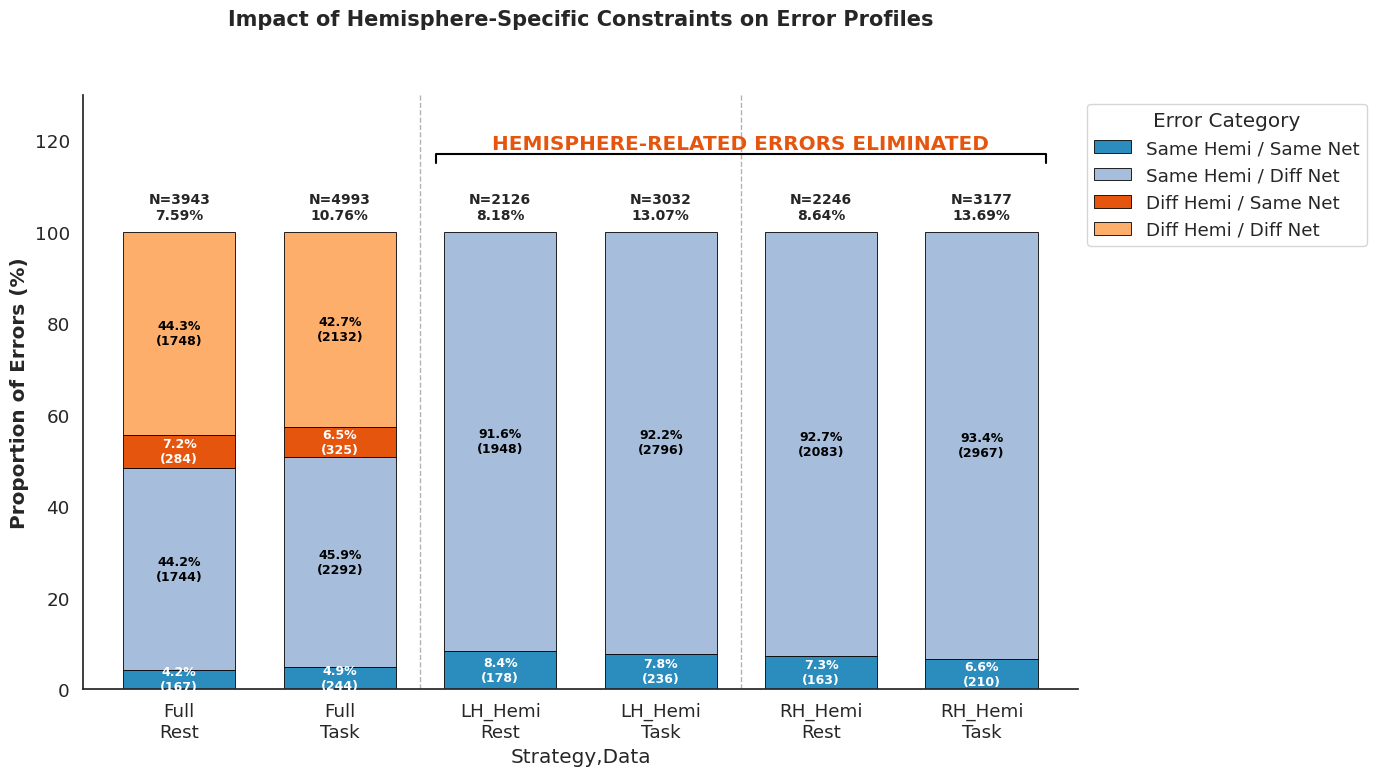

In [12]:
# 1. Clean and Parse Data
df = error_df.copy()
df.columns = ["Strategy", "Data", "N", "Rate", "SH_SN", "SH_DN", "DH_SN", "DH_DN"]

# Extract counts and percentages from strings like "167 (4.2%)"
cols_to_parse = ["SH_SN", "SH_DN", "DH_SN", "DH_DN"]
for col in cols_to_parse:
    df[[f"{col}_count", f"{col}_pct"]] = df[col].str.extract(r'(\d+) \(([\d.]+)%\)').astype(float)

# 2. Setup Plot
sns.set_style("white")
fig, ax = plt.subplots(figsize=(14, 8), dpi=100)

# Colors: Blues (Same Hemi), Oranges (Diff Hemi)
colors = ['#2b8cbe', '#a6bddb', '#e6550d', '#fdae6b']
labels = ["Same Hemi / Same Net", "Same Hemi / Diff Net", "Diff Hemi / Same Net", "Diff Hemi / Diff Net"]

# 3. Plot Stacked Bars
pct_cols = [f"{c}_pct" for c in cols_to_parse]
df_plot = df.set_index(['Strategy', 'Data'])[pct_cols]
df_plot.columns = labels
df_plot.plot(kind='bar', stacked=True, color=colors, ax=ax, width=0.7, edgecolor='black', linewidth=0.6)

# 4. Annotations
for i, (idx, row) in enumerate(df.iterrows()):
    cum_height = 0
    for j, col in enumerate(cols_to_parse):
        pct, count = row[f"{col}_pct"], int(row[f"{col}_count"])
        if pct > 2.0:  # Only label if visible
            ax.text(i, cum_height + (pct/2), f"{pct:.1f}%\n({count})", 
                    ha='center', va='center', color="white" if j in [0, 2] else "black", 
                    fontsize=9, fontweight='bold')
        cum_height += pct
    
    # Header labels (N and Rate)
    ax.text(i, 102, f"N={int(row['N'])}\n{row['Rate']}", ha='center', va='bottom', fontsize=10, fontweight='bold')

# 5. Visual Callouts & Polish
[ax.axvline(x, color='black', ls='--', lw=1, alpha=0.3) for x in [1.5, 3.5]]

# Bracket for Hemisphere-specific models
ax.plot([1.6, 1.6, 5.4, 5.4], [115, 117, 117, 115], color="black", lw=1.5)
ax.text(3.5, 118, "HEMISPHERE-RELATED ERRORS ELIMINATED", ha='center', fontweight='bold', color='#e6550d')

ax.set_ylabel("Proportion of Errors (%)", fontweight='bold')
ax.set_title("Impact of Hemisphere-Specific Constraints on Error Profiles", fontsize=15, pad=50, fontweight='bold')
ax.set_xticklabels([f"{s}\n{d}" for s, d in df_plot.index], rotation=0)
ax.set_ylim(0, 130)
ax.legend(title="Error Category", bbox_to_anchor=(1, 1), loc='upper left')
sns.despine()

plt.tight_layout()
plt.show()

In [60]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# ============================================================================
# 1. COLOR CONFIGURATION (Scientific Standard)
# ============================================================================
# Mapping networks to standard atlas colors (Yeo/Schaefer style)
NETWORK_COLORS = {
    'Visual': 'rgb(120, 18, 134)',                  # Purple
    'Somatomotor': 'rgb(70, 130, 180)',            # Blue
    'Dorsal Attention': 'rgb(0, 118, 14)',          # Green
    'Salience/Ventral Attention': 'rgb(196, 58, 250)', # Fuchsia
    'Limbic': 'rgb(220, 248, 164)',                # Cream/Yellow
    'Control': 'rgb(230, 148, 34)',                # Orange
    'Default': 'rgb(205, 62, 78)',                 # Red
    'Subcortical': 'rgb(12, 123, 174)',            # Blue
    'Other': 'rgb(128, 128, 128)'                  # Gray
}

# ============================================================================
# 2. SANKEY PLOTTING FUNCTION WITH FULL FLOW ANNOTATIONS
# ============================================================================

def plot_multilevel_sankey_annotated(df, title="Network Classification Error Flow"):
    """
    Creates a 3-tier Sankey with Network-specific coloring and flow percentage annotations
    throughout ALL stages of the flow.
    """
    nets = sorted(df['Source_Net'].unique())
    hemis = ["Left", "Right"]
    
    # 1. Build Node List and Node Color List
    nodes = []
    node_colors = []
    
    # Tier 0: True Networks
    for n in nets:
        nodes.append(f"True {n}")
        node_colors.append(NETWORK_COLORS.get(n, NETWORK_COLORS['Other']))
    
    # Tier 1: Source Hemispheres
    for h in hemis:
        nodes.append(f"Source {h}")
        node_colors.append('rgb(100, 100, 100)') # Neutral Dark Gray
        
    # Tier 2: Predicted Hemispheres
    for h in hemis:
        nodes.append(f"Pred {h}")
        node_colors.append('rgb(100, 100, 100)')
        
    # Tier 3: Predicted Networks
    for n in nets:
        nodes.append(f"Predicted {n}")
        node_colors.append(NETWORK_COLORS.get(n, NETWORK_COLORS['Other']))
        
    node_map = {name: i for i, name in enumerate(nodes)}
    links = []
    total_errors = df['Value'].sum()

    # Helper to convert RGB to RGBA for links (translucency)
    def to_rgba(rgb_str, alpha=0.3):
        return rgb_str.replace('rgb', 'rgba').replace(')', f', {alpha})')

    # --- Flow 1: True Network -> Source Hemisphere ---
    f1 = df.groupby(['Source_Net', 'Source_Hemi'])['Value'].sum().reset_index()
    for _, r in f1.iterrows():
        pct = (r['Value'] / total_errors) * 100
        color = to_rgba(NETWORK_COLORS.get(r['Source_Net'], NETWORK_COLORS['Other']))
        links.append(dict(
            source=node_map[f"True {r['Source_Net']}"], 
            target=node_map[f"Source {r['Source_Hemi']}"], 
            value=r['Value'],
            color=color,
            label=f"{pct:.1f}%"
        ))
        
    # --- Flow 2: Source Hemisphere -> Target Hemisphere (Inter-hemispheric Flow) ---
    f2 = df.groupby(['Source_Hemi', 'Target_Hemi'])['Value'].sum().reset_index()
    for _, r in f2.iterrows():
        pct = (r['Value'] / total_errors) * 100
        links.append(dict(
            source=node_map[f"Source {r['Source_Hemi']}"], 
            target=node_map[f"Pred {r['Target_Hemi']}"], 
            value=r['Value'],
            color='rgba(200, 200, 200, 0.4)',
            label=f"{pct:.1f}%"
        ))
        
    # --- Flow 3: Target Hemisphere -> Predicted Network ---
    f3 = df.groupby(['Target_Hemi', 'Target_Net'])['Value'].sum().reset_index()
    for _, r in f3.iterrows():
        pct = (r['Value'] / total_errors) * 100
        color = to_rgba(NETWORK_COLORS.get(r['Target_Net'], NETWORK_COLORS['Other']))
        links.append(dict(
            source=node_map[f"Pred {r['Target_Hemi']}"], 
            target=node_map[f"Predicted {r['Target_Net']}"], 
            value=r['Value'],
            color=color,
            label=f"{pct:.1f}%"
        ))

    # 3. Create Figure
    fig = go.Figure(data=[go.Sankey(
        arrangement="perpendicular",
        node=dict(
            pad=15, thickness=20,
            line=dict(color="black", width=0.5),
            label=[n.split(' ')[-1] for n in nodes],
            color=node_colors
        ),
        link=dict(
            source=[l['source'] for l in links],
            target=[l['target'] for l in links],
            value=[l['value'] for l in links],
            color=[l['color'] for l in links],
            customdata=[l.get('label', "") for l in links],
            hovertemplate='<b>Flow Amount:</b> %{value}<br><b>% of Total Errors:</b> %{customdata}<extra></extra>'
        )
    )])

    # 4. Add Section Annotations (Tier Labels)
    fig.update_layout(
        title_text=f"<b>{title}</b><br><sup>Total Errors: {int(total_errors)}</sup>",
        font_size=12,
        height=800,
        annotations=[
            dict(x=0, y=1.05, showarrow=False, text="<b>TRUE NETWORK</b>", 
                 xref="paper", yref="paper", font=dict(size=14, color="black")),
            dict(x=0.33, y=1.05, showarrow=False, text="<b>ORIGIN HEMI</b>", 
                 xref="paper", yref="paper", font=dict(size=14)),
            dict(x=0.66, y=1.05, showarrow=False, text="<b>PRED HEMI</b>", 
                 xref="paper", yref="paper", font=dict(size=14)),
            dict(x=1, y=1.05, showarrow=False, text="<b>PREDICTED NETWORK</b>", 
                 xref="paper", yref="paper", font=dict(size=14))
        ]
    )
    return fig

# --- EXECUTION ---
fig = plot_multilevel_sankey_annotated(sankey_data, 
                                       title="Neuroimaging Classification Error Propagation")
fig.show()

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# ============================================================================
# 1. CONFIGURATION & COLOR MAPPING
# ============================================================================
NETWORK_COLORS = {
    'Visual': 'rgb(120, 18, 134)', 
    'Somatomotor': 'rgb(70, 130, 180)',
    'Dorsal Attention': 'rgb(0, 118, 14)', 
    'Salience/Ventral Attention': 'rgb(196, 58, 250)',
    'Limbic': 'rgb(220, 248, 164)', 
    'Control': 'rgb(230, 148, 34)',
    'Default': 'rgb(205, 62, 78)', 
    'Subcortical': 'rgb(12, 123, 174)', 
    'Other': 'rgb(128, 128, 128)'
}

def to_rgba(rgb_str, alpha=0.3):
    return rgb_str.replace('rgb', 'rgba').replace(')', f', {alpha})')

# ============================================================================
# 2. DATA EXTRACTION FUNCTION
# ============================================================================
def extract_sankey_data(cm, region_info):
    """Extract error flow data from confusion matrix"""
    rows = []
    
    # Determine hemisphere - USE THE HEMISPHERE COLUMN!
    if 'hemisphere' in region_info.columns:
        is_left = region_info['hemisphere'].str.lower() == 'left'
    else:
        # Fallback if no hemisphere column
        is_left = region_info['region_name'].str.startswith(('LH_', 'L_')) | \
                  region_info['region_name'].str.contains('_L')
    
    region_info = region_info.reset_index(drop=True)
    
    for i in range(cm.shape[0]):
        if i >= len(region_info):
            continue
            
        true_net = region_info.iloc[i]['major_network']
        true_hemi = "Left" if is_left.iloc[i] else "Right"
        
        for j in range(cm.shape[1]):
            if i == j or cm[i, j] == 0:  # Skip diagonal and zeros
                continue
                
            pred_net = region_info.iloc[j]['major_network']
            pred_hemi = "Left" if is_left.iloc[j] else "Right"
            
            rows.append({
                'Source_Net': true_net,
                'Source_Hemi': true_hemi,
                'Target_Hemi': pred_hemi,
                'Target_Net': pred_net,
                'Value': cm[i, j]
            })
    
    return pd.DataFrame(rows)

# ============================================================================
# 3. TRACE GENERATOR FUNCTION
# ============================================================================
def create_sankey_trace(df, domain_dict):
    """Generates a single Sankey trace for a specific grid domain."""
    if df.empty:
        return None
    
    # Get all networks present in this data
    all_networks = sorted(set(df['Source_Net'].unique()) | set(df['Target_Net'].unique()))
    
    # Get hemispheres present
    source_hemis = sorted(df['Source_Hemi'].unique())
    target_hemis = sorted(df['Target_Hemi'].unique())
    
    # Build nodes
    nodes = []
    node_colors = []
    
    # Tier 0: True Networks
    for n in all_networks:
        nodes.append(f"True {n}")
        node_colors.append(NETWORK_COLORS.get(n, NETWORK_COLORS['Other']))
    
    # Tier 1: Source Hemispheres
    for h in source_hemis:
        nodes.append(f"Src {h}")
        node_colors.append('rgb(100, 100, 100)')
    
    # Tier 2: Target Hemispheres
    for h in target_hemis:
        nodes.append(f"Pred {h}")
        node_colors.append('rgb(100, 100, 100)')
    
    # Tier 3: Predicted Networks
    for n in all_networks:
        nodes.append(f"Predicted {n}")
        node_colors.append(NETWORK_COLORS.get(n, NETWORK_COLORS['Other']))
    
    node_map = {name: i for i, name in enumerate(nodes)}
    links = []
    total_val = df['Value'].sum()

    # Flow 1: True Net -> Source Hemi
    f1 = df.groupby(['Source_Net', 'Source_Hemi'])['Value'].sum().reset_index()
    for _, r in f1.iterrows():
        pct = (r['Value'] / total_val) * 100
        links.append(dict(
            source=node_map[f"True {r['Source_Net']}"], 
            target=node_map[f"Src {r['Source_Hemi']}"],
            value=r['Value'], 
            color=to_rgba(NETWORK_COLORS.get(r['Source_Net'], NETWORK_COLORS['Other'])),
            label=f"{pct:.1f}%"
        ))

    # Flow 2: Source Hemi -> Pred Hemi
    f2 = df.groupby(['Source_Hemi', 'Target_Hemi'])['Value'].sum().reset_index()
    for _, r in f2.iterrows():
        links.append(dict(
            source=node_map[f"Src {r['Source_Hemi']}"], 
            target=node_map[f"Pred {r['Target_Hemi']}"],
            value=r['Value'], 
            color='rgba(200, 200, 200, 0.4)'
        ))

    # Flow 3: Pred Hemi -> Predicted Net
    f3 = df.groupby(['Target_Hemi', 'Target_Net'])['Value'].sum().reset_index()
    for _, r in f3.iterrows():
        links.append(dict(
            source=node_map[f"Pred {r['Target_Hemi']}"], 
            target=node_map[f"Predicted {r['Target_Net']}"],
            value=r['Value'], 
            color=to_rgba(NETWORK_COLORS.get(r['Target_Net'], NETWORK_COLORS['Other']))
        ))

    return go.Sankey(
        domain=domain_dict,
        arrangement="perpendicular",
        node=dict(
            pad=15, 
            thickness=15, 
            line=dict(color="black", width=0.5),
            label=[n.split(' ')[-1] for n in nodes], 
            color=node_colors
        ),
        link=dict(
            source=[l['source'] for l in links], 
            target=[l['target'] for l in links],
            value=[l['value'] for l in links], 
            color=[l['color'] for l in links],
            customdata=[l.get('label', "") for l in links],
            hovertemplate='<b>Errors:</b> %{value}<br><b>%:</b> %{customdata}<extra></extra>'
        )
    )

# ============================================================================
# 4. GRID CONSTRUCTION - USING YOUR ACTUAL DATA
# ============================================================================

# Mapping your actual variables to the grid structure
mapping = {
    ("Full Strategy", "Rest"): (confusion_matrix_cv_full, region_info_full),
    ("Full Strategy", "Task"): (confusion_matrix_task_full, region_info_full),
    ("LH Strategy", "Rest"):   (confusion_matrix_cv_lh, region_info_lh),
    ("LH Strategy", "Task"):   (confusion_matrix_task_lh, region_info_lh),
    ("RH Strategy", "Rest"):   (confusion_matrix_cv_rh, region_info_rh),
    ("RH Strategy", "Task"):   (confusion_matrix_task_rh, region_info_rh)
}

strategies = ["Full Strategy", "LH Strategy", "RH Strategy"]
conditions = ["Rest", "Task"]

fig = go.Figure()
annotations = []

for r_idx, strat in enumerate(strategies):
    for c_idx, cond in enumerate(conditions):
        x_range = [c_idx * 0.5, (c_idx + 1) * 0.5]
        y_range = [1 - (r_idx + 1) * 0.33, 1 - r_idx * 0.33]
        
        # Get the data for this subplot
        cm, region_info = mapping[(strat, cond)]
        
        # Extract flow data
        df_sub = extract_sankey_data(cm, region_info)
        
        # Create trace
        if not df_sub.empty:
            trace = create_sankey_trace(
                df_sub, 
                {'x': [x_range[0]+0.02, x_range[1]-0.02], 
                 'y': [y_range[0]+0.04, y_range[1]-0.04]}
            )
            if trace is not None:
                fig.add_trace(trace)
        
        # Add title annotation
        annotations.append(dict(
            x=(x_range[0] + x_range[1]) / 2, 
            y=y_range[1] - 0.01,
            text=f"<b>{strat}: {cond}</b>", 
            showarrow=False, 
            xref="paper", 
            yref="paper", 
            font=dict(size=12)
        ))
        
        # Add tier labels
        tier_y = y_range[1] - 0.03
        tier_labels = ["TRUE", "ORIGIN", "PRED", "PRED"]
        for t_idx, txt in enumerate(tier_labels):
            annotations.append(dict(
                x=x_range[0] + 0.02 + t_idx * ((x_range[1] - 0.02) - (x_range[0] + 0.02)) / 3,
                y=tier_y,
                text=txt,
                showarrow=False,
                xref="paper",
                yref="paper",
                font=dict(size=8, color="gray")
            ))

fig.update_layout(
    title_text="<b>Brain Network Classification Error Flow: Multi-Strategy Comparison</b>",
    height=1200, 
    width=1400,
    annotations=annotations,
    margin=dict(t=80, b=40, l=40, r=40),
    paper_bgcolor='white'
)

fig.show()

# Optional: Save
# fig.write_image("sankey_6subplot_comparison.png", width=1400, height=1200, scale=2)

In [61]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ============================================================================
# 1. CONFIGURATION & COLOR MAPPING
# ============================================================================
NETWORK_COLORS = {
    'Visual': 'rgb(120, 18, 134)', 
    'Somatomotor': 'rgb(70, 130, 180)',
    'Dorsal Attention': 'rgb(0, 118, 14)', 
    'Salience/Ventral Attention': 'rgb(196, 58, 250)',
    'Limbic': 'rgb(220, 248, 164)', 
    'Control': 'rgb(230, 148, 34)',
    'Default': 'rgb(205, 62, 78)', 
    'Subcortical': 'rgb(12, 123, 174)', 
    'Other': 'rgb(128, 128, 128)'
}

def to_rgba(rgb_str, alpha=0.3):
    return rgb_str.replace('rgb', 'rgba').replace(')', f', {alpha})')

# ============================================================================
# 2. DATA EXTRACTION FUNCTION
# ============================================================================
def extract_sankey_data(cm, region_info):
    """Extract error flow data from confusion matrix"""
    rows = []
    
    # Determine hemisphere
    if 'hemisphere' in region_info.columns:
        is_left = region_info['hemisphere'].str.lower() == 'left'
    else:
        is_left = region_info['region_name'].str.startswith(('LH_', 'L_')) | \
                  region_info['region_name'].str.contains('_L')
    
    region_info = region_info.reset_index(drop=True)
    
    for i in range(cm.shape[0]):
        if i >= len(region_info):
            continue
            
        true_net = region_info.iloc[i]['major_network']
        true_hemi = "Left" if is_left.iloc[i] else "Right"
        
        for j in range(cm.shape[1]):
            if i == j or cm[i, j] == 0:
                continue
                
            pred_net = region_info.iloc[j]['major_network']
            pred_hemi = "Left" if is_left.iloc[j] else "Right"
            
            rows.append({
                'Source_Net': true_net,
                'Source_Hemi': true_hemi,
                'Target_Hemi': pred_hemi,
                'Target_Net': pred_net,
                'Value': cm[i, j]
            })
    
    return pd.DataFrame(rows)

# ============================================================================
# 3. CALCULATE KEY METRICS
# ============================================================================
def calculate_metrics(df):
    """Calculate key error pattern metrics"""
    if df.empty:
        return {}
    
    total_errors = df['Value'].sum()
    
    # Inter-hemispheric errors (crossing errors)
    inter_hemi = df[df['Source_Hemi'] != df['Target_Hemi']]['Value'].sum()
    inter_hemi_pct = (inter_hemi / total_errors) * 100 if total_errors > 0 else 0
    
    # Intra-hemispheric errors (same hemisphere)
    intra_hemi = df[df['Source_Hemi'] == df['Target_Hemi']]['Value'].sum()
    intra_hemi_pct = (intra_hemi / total_errors) * 100 if total_errors > 0 else 0
    
    # Network-level errors
    network_errors = df.groupby('Source_Net')['Value'].sum().sort_values(ascending=False)
    top_error_network = network_errors.index[0] if len(network_errors) > 0 else "N/A"
    top_error_pct = (network_errors.iloc[0] / total_errors) * 100 if len(network_errors) > 0 else 0
    
    # Cross-network errors (different networks)
    cross_network = df[df['Source_Net'] != df['Target_Net']]['Value'].sum()
    cross_network_pct = (cross_network / total_errors) * 100 if total_errors > 0 else 0
    
    return {
        'total_errors': int(total_errors),
        'inter_hemi': int(inter_hemi),
        'inter_hemi_pct': inter_hemi_pct,
        'intra_hemi': int(intra_hemi),
        'intra_hemi_pct': intra_hemi_pct,
        'top_error_network': top_error_network,
        'top_error_pct': top_error_pct,
        'cross_network_pct': cross_network_pct
    }

# ============================================================================
# 4. ENHANCED SANKEY TRACE GENERATOR
# ============================================================================
def create_sankey_trace(df, domain_dict, show_percentages=True):
    """Generates a single Sankey trace with enhanced flow tracking"""
    if df.empty:
        return None
    
    all_networks = sorted(set(df['Source_Net'].unique()) | set(df['Target_Net'].unique()))
    source_hemis = sorted(df['Source_Hemi'].unique())
    target_hemis = sorted(df['Target_Hemi'].unique())
    
    nodes = []
    node_colors = []
    
    # Tier 0: True Networks
    for n in all_networks:
        nodes.append(f"True {n}")
        node_colors.append(NETWORK_COLORS.get(n, NETWORK_COLORS['Other']))
    
    # Tier 1: Source Hemispheres
    for h in source_hemis:
        nodes.append(f"Src {h}")
        node_colors.append('rgb(100, 100, 100)')
    
    # Tier 2: Target Hemispheres
    for h in target_hemis:
        nodes.append(f"Pred {h}")
        node_colors.append('rgb(100, 100, 100)')
    
    # Tier 3: Predicted Networks
    for n in all_networks:
        nodes.append(f"Predicted {n}")
        node_colors.append(NETWORK_COLORS.get(n, NETWORK_COLORS['Other']))
    
    node_map = {name: i for i, name in enumerate(nodes)}
    links = []
    total_val = df['Value'].sum()

    # Flow 1: True Net -> Source Hemi
    f1 = df.groupby(['Source_Net', 'Source_Hemi'])['Value'].sum().reset_index()
    for _, r in f1.iterrows():
        pct = (r['Value'] / total_val) * 100
        links.append(dict(
            source=node_map[f"True {r['Source_Net']}"], 
            target=node_map[f"Src {r['Source_Hemi']}"],
            value=r['Value'], 
            color=to_rgba(NETWORK_COLORS.get(r['Source_Net'], NETWORK_COLORS['Other'])),
            label=f"{pct:.1f}%" if show_percentages else ""
        ))

    # Flow 2: Source Hemi -> Pred Hemi (KEY FLOW - Inter-hemispheric crossing)
    f2 = df.groupby(['Source_Hemi', 'Target_Hemi'])['Value'].sum().reset_index()
    for _, r in f2.iterrows():
        pct = (r['Value'] / total_val) * 100
        # Highlight inter-hemispheric crossings with different color
        is_crossing = r['Source_Hemi'] != r['Target_Hemi']
        color = 'rgba(255, 100, 100, 0.5)' if is_crossing else 'rgba(150, 150, 150, 0.4)'
        
        links.append(dict(
            source=node_map[f"Src {r['Source_Hemi']}"], 
            target=node_map[f"Pred {r['Target_Hemi']}"],
            value=r['Value'], 
            color=color,
            label=f"{pct:.1f}%" if show_percentages else ""
        ))

    # Flow 3: Pred Hemi -> Predicted Net
    f3 = df.groupby(['Target_Hemi', 'Target_Net'])['Value'].sum().reset_index()
    for _, r in f3.iterrows():
        pct = (r['Value'] / total_val) * 100
        links.append(dict(
            source=node_map[f"Pred {r['Target_Hemi']}"], 
            target=node_map[f"Predicted {r['Target_Net']}"],
            value=r['Value'], 
            color=to_rgba(NETWORK_COLORS.get(r['Target_Net'], NETWORK_COLORS['Other'])),
            label=f"{pct:.1f}%" if show_percentages else ""
        ))

    return go.Sankey(
        domain=domain_dict,
        arrangement="perpendicular",
        node=dict(
            pad=20, 
            thickness=20, 
            line=dict(color="black", width=0.5),
            label=[n.split(' ')[-1] for n in nodes], 
            color=node_colors
        ),
        link=dict(
            source=[l['source'] for l in links], 
            target=[l['target'] for l in links],
            value=[l['value'] for l in links], 
            color=[l['color'] for l in links],
            customdata=[l.get('label', "") for l in links],
            hovertemplate='<b>Errors:</b> %{value}<br><b>% of Total:</b> %{customdata}<extra></extra>'
        )
    )

# ============================================================================
# 5. FIGURE 1: TWO-PANEL COMPARISON (Rest vs Task)
# ============================================================================

def create_figure1_comparison(confusion_matrix_cv_full, confusion_matrix_task_full, 
                               region_info_full):
    """
    Creates Figure 1: Detailed comparison of Rest vs Task error patterns
    for Full Strategy only (your main thesis finding)
    """
    
    # Extract data for both conditions
    df_rest = extract_sankey_data(confusion_matrix_cv_full, region_info_full)
    df_task = extract_sankey_data(confusion_matrix_task_full, region_info_full)
    
    # Calculate metrics
    metrics_rest = calculate_metrics(df_rest)
    metrics_task = calculate_metrics(df_task)
    
    # Calculate change
    inter_hemi_change = metrics_task['inter_hemi_pct'] - metrics_rest['inter_hemi_pct']
    
    # Create figure
    fig = go.Figure()
    
    # Panel A: Resting State (Left side)
    trace_rest = create_sankey_trace(
        df_rest,
        {'x': [0.02, 0.48], 'y': [0.15, 0.85]}
    )
    if trace_rest is not None:
        fig.add_trace(trace_rest)
    
    # Panel B: Task State (Right side)
    trace_task = create_sankey_trace(
        df_task,
        {'x': [0.52, 0.98], 'y': [0.15, 0.85]}
    )
    if trace_task is not None:
        fig.add_trace(trace_task)
    
    # Create annotations
    annotations = []
    
    # Panel titles
    annotations.extend([
        dict(x=0.25, y=0.95, text="<b>A) Resting State (Training Data)</b>",
             showarrow=False, xref="paper", yref="paper", 
             font=dict(size=16, color="black")),
        dict(x=0.75, y=0.95, text="<b>B) Task State (Test Data)</b>",
             showarrow=False, xref="paper", yref="paper", 
             font=dict(size=16, color="black"))
    ])
    
    # Tier labels for Panel A
    tier_labels = ["TRUE NET", "ORIGIN", "PRED", "PRED NET"]
    for i, label in enumerate(tier_labels):
        annotations.append(dict(
            x=0.02 + i * 0.115,
            y=0.88,
            text=f"<i>{label}</i>",
            showarrow=False,
            xref="paper",
            yref="paper",
            font=dict(size=10, color="gray")
        ))
    
    # Tier labels for Panel B
    for i, label in enumerate(tier_labels):
        annotations.append(dict(
            x=0.52 + i * 0.115,
            y=0.88,
            text=f"<i>{label}</i>",
            showarrow=False,
            xref="paper",
            yref="paper",
            font=dict(size=10, color="gray")
        ))
    
    # Metrics boxes for Panel A (Rest)
    annotations.extend([
        dict(x=0.25, y=0.08, 
             text=f"<b>Total Errors:</b> {metrics_rest['total_errors']}<br>" +
                  f"<b>Inter-hemispheric:</b> {metrics_rest['inter_hemi_pct']:.1f}%<br>" +
                  f"<b>Intra-hemispheric:</b> {metrics_rest['intra_hemi_pct']:.1f}%<br>" +
                  f"<b>Top Error Network:</b> {metrics_rest['top_error_network']} ({metrics_rest['top_error_pct']:.1f}%)",
             showarrow=False, xref="paper", yref="paper",
             font=dict(size=11), align="center",
             bgcolor="rgba(240, 240, 240, 0.8)",
             bordercolor="black", borderwidth=1)
    ])
    
    # Metrics boxes for Panel B (Task)
    change_symbol = "↑" if inter_hemi_change > 0 else "↓"
    change_color = "red" if inter_hemi_change > 0 else "green"
    
    annotations.extend([
        dict(x=0.75, y=0.08,
             text=f"<b>Total Errors:</b> {metrics_task['total_errors']}<br>" +
                  f"<b>Inter-hemispheric:</b> {metrics_task['inter_hemi_pct']:.1f}% " +
                  f"<span style='color:{change_color}'>{change_symbol}{abs(inter_hemi_change):.1f}pp</span><br>" +
                  f"<b>Intra-hemispheric:</b> {metrics_task['intra_hemi_pct']:.1f}%<br>" +
                  f"<b>Top Error Network:</b> {metrics_task['top_error_network']} ({metrics_task['top_error_pct']:.1f}%)",
             showarrow=False, xref="paper", yref="paper",
             font=dict(size=11), align="center",
             bgcolor="rgba(240, 240, 240, 0.8)",
             bordercolor="black", borderwidth=1)
    ])
    
    # Add interpretation box
    annotations.append(dict(
        x=0.5, y=0.01,
        text="<i>Red flows indicate inter-hemispheric crossings | Gray flows indicate intra-hemispheric errors</i>",
        showarrow=False, xref="paper", yref="paper",
        font=dict(size=10, color="gray"), align="center"
    ))
    
    fig.update_layout(
        title_text="<b>Figure 1: Brain Network Classification Error Flow - Rest vs Task Comparison</b><br>" +
                   "<sup>Full-Brain Training Strategy | Error-as-Signal Framework</sup>",
        height=900,
        width=1600,
        annotations=annotations,
        margin=dict(t=100, b=100, l=40, r=40),
        paper_bgcolor='white',
        font=dict(family="Arial, sans-serif")
    )
    
    return fig, metrics_rest, metrics_task

# ============================================================================
# EXECUTION
# ============================================================================

# Generate Figure 1
fig1, metrics_rest, metrics_task = create_figure1_comparison(
    confusion_matrix_cv_full, 
    confusion_matrix_task_full, 
    region_info_full
)

fig1.show()

# Optional: Save
# fig1.write_html("figure1_rest_vs_task_comparison.html")
# fig1.write_image("figure1_rest_vs_task_comparison.png", width=1600, height=900, scale=2)

print("\n" + "="*60)
print("FIGURE 1 METRICS SUMMARY")
print("="*60)
print(f"\nResting State:")
print(f"  Total Errors: {metrics_rest['total_errors']}")
print(f"  Inter-hemispheric: {metrics_rest['inter_hemi_pct']:.2f}%")
print(f"  Top Error Network: {metrics_rest['top_error_network']}")

print(f"\nTask State:")
print(f"  Total Errors: {metrics_task['total_errors']}")
print(f"  Inter-hemispheric: {metrics_task['inter_hemi_pct']:.2f}%")
print(f"  Top Error Network: {metrics_task['top_error_network']}")

print(f"\nChange (Task vs Rest):")
print(f"  Inter-hemispheric: {metrics_task['inter_hemi_pct'] - metrics_rest['inter_hemi_pct']:+.2f} pp")
print("="*60)


FIGURE 1 METRICS SUMMARY

Resting State:
  Total Errors: 3943
  Inter-hemispheric: 51.53%
  Top Error Network: Subcortical

Task State:
  Total Errors: 4993
  Inter-hemispheric: 49.21%
  Top Error Network: Subcortical

Change (Task vs Rest):
  Inter-hemispheric: -2.33 pp


The inter-hemisphere error decreased during task slightly by 2.33 percentage points, the absolute number of inter-hemispheric erros actually increased by 425 errors. Intra hemispheric increased even more by 625 errors -- which causes relative decrease. This suggests that the Gender Stroop task induces greater within-hemisphere network confusion rather than primarily disrupting cross-hemispheric communication. This pattern may reflect task-specific hemispheric specialization, where each hemisphere increases its internal processing load, leading to more localized network overlap and confusion. This finding actually supports the error-as-signal framework—the task reveals a specific type of functional reorganization: increased within-hemisphere processing demands."

In [63]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ============================================================================
# 1. CONFIGURATION
# ============================================================================
NETWORK_COLORS = {
    'Visual': 'rgb(120, 18, 134)', 
    'Somatomotor': 'rgb(70, 130, 180)',
    'Dorsal Attention': 'rgb(0, 118, 14)', 
    'Salience/Ventral Attention': 'rgb(196, 58, 250)',
    'Limbic': 'rgb(220, 248, 164)', 
    'Control': 'rgb(230, 148, 34)',
    'Default': 'rgb(205, 62, 78)', 
    'Subcortical': 'rgb(12, 123, 174)', 
    'Other': 'rgb(128, 128, 128)'
}

# ============================================================================
# 2. DATA EXTRACTION (REUSE FROM FIGURE 1)
# ============================================================================
def extract_sankey_data(cm, region_info):
    """Extract error flow data from confusion matrix"""
    rows = []
    
    if 'hemisphere' in region_info.columns:
        is_left = region_info['hemisphere'].str.lower() == 'left'
    else:
        is_left = region_info['region_name'].str.startswith(('LH_', 'L_')) | \
                  region_info['region_name'].str.contains('_L')
    
    region_info = region_info.reset_index(drop=True)
    
    for i in range(cm.shape[0]):
        if i >= len(region_info):
            continue
            
        true_net = region_info.iloc[i]['major_network']
        true_hemi = "Left" if is_left.iloc[i] else "Right"
        
        for j in range(cm.shape[1]):
            if i == j or cm[i, j] == 0:
                continue
                
            pred_net = region_info.iloc[j]['major_network']
            pred_hemi = "Left" if is_left.iloc[j] else "Right"
            
            rows.append({
                'Source_Net': true_net,
                'Source_Hemi': true_hemi,
                'Target_Hemi': pred_hemi,
                'Target_Net': pred_net,
                'Value': cm[i, j]
            })
    
    return pd.DataFrame(rows)

# ============================================================================
# 3. COMPREHENSIVE METRICS EXTRACTION
# ============================================================================
def extract_all_metrics(mapping):
    """Extract metrics for all strategies and conditions"""
    
    results = []
    
    for (strategy, condition), (cm, region_info) in mapping.items():
        df = extract_sankey_data(cm, region_info)
        
        if df.empty:
            continue
        
        total_errors = df['Value'].sum()
        
        # Inter-hemispheric errors
        inter_hemi = df[df['Source_Hemi'] != df['Target_Hemi']]['Value'].sum()
        inter_hemi_pct = (inter_hemi / total_errors) * 100 if total_errors > 0 else 0
        
        # Intra-hemispheric errors
        intra_hemi = df[df['Source_Hemi'] == df['Target_Hemi']]['Value'].sum()
        intra_hemi_pct = (intra_hemi / total_errors) * 100 if total_errors > 0 else 0
        
        # Left-to-Right and Right-to-Left
        left_to_right = df[(df['Source_Hemi'] == 'Left') & (df['Target_Hemi'] == 'Right')]['Value'].sum()
        right_to_left = df[(df['Source_Hemi'] == 'Right') & (df['Target_Hemi'] == 'Left')]['Value'].sum()
        
        l2r_pct = (left_to_right / total_errors) * 100 if total_errors > 0 else 0
        r2l_pct = (right_to_left / total_errors) * 100 if total_errors > 0 else 0
        
        results.append({
            'Strategy': strategy,
            'Condition': condition,
            'Total_Errors': int(total_errors),
            'Inter_Hemi_Pct': inter_hemi_pct,
            'Intra_Hemi_Pct': intra_hemi_pct,
            'L2R_Pct': l2r_pct,
            'R2L_Pct': r2l_pct
        })
    
    return pd.DataFrame(results)

def extract_network_metrics(mapping):
    """Extract network-specific error patterns"""
    
    results = []
    
    for (strategy, condition), (cm, region_info) in mapping.items():
        df = extract_sankey_data(cm, region_info)
        
        if df.empty:
            continue
        
        total_errors = df['Value'].sum()
        
        # Network-wise errors (as source of error)
        network_errors = df.groupby('Source_Net')['Value'].sum()
        
        for network, errors in network_errors.items():
            pct = (errors / total_errors) * 100 if total_errors > 0 else 0
            
            results.append({
                'Strategy': strategy,
                'Condition': condition,
                'Network': network,
                'Error_Count': int(errors),
                'Error_Pct': pct
            })
    
    return pd.DataFrame(results)

# ============================================================================
# 4. FIGURE 2: THREE-PANEL COMPARATIVE ANALYSIS
# ============================================================================

def create_figure2_comparative(mapping):
    """
    Creates Figure 2: Quantitative comparison across all strategies
    Panel A: Inter-hemispheric error rates
    Panel B: Network-specific error contributions
    Panel C: Strategy performance comparison
    """
    
    # Extract all metrics
    df_metrics = extract_all_metrics(mapping)
    df_network = extract_network_metrics(mapping)
    
    # Create subplots
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=(
            "<b>A) Inter-Hemispheric Error Rates</b>",
            "<b>B) Hemispheric Asymmetry (L→R vs R→L)</b>",
            "<b>C) Network Error Contributions (Full Strategy)</b>",
            "<b>D) Strategy Comparison: Total Error Rates</b>"
        ),
        specs=[
            [{"type": "bar"}, {"type": "bar"}],
            [{"type": "bar"}, {"type": "bar"}]
        ],
        vertical_spacing=0.15,
        horizontal_spacing=0.12
    )
    
    # ========================================================================
    # PANEL A: Inter-hemispheric Error Rates (All Strategies)
    # ========================================================================
    
    strategies = ["Full Strategy", "LH Strategy", "RH Strategy"]
    conditions = ["Rest", "Task"]
    
    for condition in conditions:
        df_cond = df_metrics[df_metrics['Condition'] == condition]
        
        fig.add_trace(
            go.Bar(
                name=condition,
                x=df_cond['Strategy'],
                y=df_cond['Inter_Hemi_Pct'],
                text=[f"{val:.1f}%" for val in df_cond['Inter_Hemi_Pct']],
                textposition='outside',
                marker_color='lightcoral' if condition == 'Task' else 'steelblue',
                showlegend=True
            ),
            row=1, col=1
        )
    
    # ========================================================================
    # PANEL B: Hemispheric Asymmetry (L→R vs R→L)
    # ========================================================================
    
    # Focus on Full Strategy only for clarity
    df_full = df_metrics[df_metrics['Strategy'] == 'Full Strategy']
    
    x_labels = [f"{row['Condition']}" for _, row in df_full.iterrows()]
    
    fig.add_trace(
        go.Bar(
            name='Left → Right',
            x=x_labels,
            y=df_full['L2R_Pct'],
            text=[f"{val:.1f}%" for val in df_full['L2R_Pct']],
            textposition='outside',
            marker_color='rgb(99, 110, 250)',
            showlegend=True
        ),
        row=1, col=2
    )
    
    fig.add_trace(
        go.Bar(
            name='Right → Left',
            x=x_labels,
            y=df_full['R2L_Pct'],
            text=[f"{val:.1f}%" for val in df_full['R2L_Pct']],
            textposition='outside',
            marker_color='rgb(239, 85, 59)',
            showlegend=True
        ),
        row=1, col=2
    )
    
    # ========================================================================
    # PANEL C: Network Error Contributions (Full Strategy Only)
    # ========================================================================
    
    df_net_full = df_network[df_network['Strategy'] == 'Full Strategy']
    
    # Get unique networks and sort by average error contribution
    networks = df_net_full.groupby('Network')['Error_Pct'].mean().sort_values(ascending=False).index.tolist()
    
    for condition in conditions:
        df_cond = df_net_full[df_net_full['Condition'] == condition]
        
        # Ensure networks are in the same order
        df_cond = df_cond.set_index('Network').reindex(networks).reset_index()
        
        fig.add_trace(
            go.Bar(
                name=f"{condition}",
                x=df_cond['Network'],
                y=df_cond['Error_Pct'],
                text=[f"{val:.1f}%" for val in df_cond['Error_Pct']],
                textposition='outside',
                marker_color='lightcoral' if condition == 'Task' else 'steelblue',
                showlegend=False
            ),
            row=2, col=1
        )
    
    # ========================================================================
    # PANEL D: Strategy Comparison - Total Error Rates
    # ========================================================================
    
    # Calculate error rate as percentage of total possible misclassifications
    # (This is more meaningful than raw counts)
    
    for condition in conditions:
        df_cond = df_metrics[df_metrics['Condition'] == condition]
        
        fig.add_trace(
            go.Bar(
                name=f"{condition}",
                x=df_cond['Strategy'],
                y=df_cond['Total_Errors'],
                text=[f"{val}" for val in df_cond['Total_Errors']],
                textposition='outside',
                marker_color='lightcoral' if condition == 'Task' else 'steelblue',
                showlegend=False
            ),
            row=2, col=2
        )
    
    # ========================================================================
    # LAYOUT UPDATES
    # ========================================================================
    
    fig.update_xaxes(title_text="Strategy", row=1, col=1)
    fig.update_yaxes(title_text="Inter-Hemispheric Errors (%)", row=1, col=1)
    
    fig.update_xaxes(title_text="Condition", row=1, col=2)
    fig.update_yaxes(title_text="Directional Error Rate (%)", row=1, col=2)
    
    fig.update_xaxes(title_text="Brain Network", row=2, col=1, tickangle=-45)
    fig.update_yaxes(title_text="Error Contribution (%)", row=2, col=1)
    
    fig.update_xaxes(title_text="Strategy", row=2, col=2)
    fig.update_yaxes(title_text="Total Misclassifications", row=2, col=2)
    
    fig.update_layout(
        title_text="<b>Figure 2: Quantitative Analysis of Classification Error Patterns</b><br>" +
                   "<sup>Comparison Across Training Strategies and Testing Conditions</sup>",
        height=1000,
        width=1600,
        showlegend=True,
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="right",
            x=1
        ),
        barmode='group',
        font=dict(family="Arial, sans-serif", size=11),
        paper_bgcolor='white',
        plot_bgcolor='rgba(240, 240, 240, 0.5)'
    )
    
    # Add grid lines for better readability
    fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')
    
    return fig, df_metrics, df_network

# ============================================================================
# 5. STATISTICAL SUMMARY GENERATION
# ============================================================================

def generate_summary_statistics(df_metrics, df_network):
    """Generate comprehensive statistical summary for thesis"""
    
    print("\n" + "="*80)
    print("FIGURE 2: COMPREHENSIVE STATISTICAL SUMMARY")
    print("="*80)
    
    # Key Finding 1: Inter-hemispheric error changes
    print("\n1. INTER-HEMISPHERIC ERROR PATTERNS")
    print("-" * 80)
    
    for strategy in df_metrics['Strategy'].unique():
        df_strat = df_metrics[df_metrics['Strategy'] == strategy]
        rest_inter = df_strat[df_strat['Condition'] == 'Rest']['Inter_Hemi_Pct'].values[0]
        task_inter = df_strat[df_strat['Condition'] == 'Task']['Inter_Hemi_Pct'].values[0]
        change = task_inter - rest_inter
        
        print(f"\n{strategy}:")
        print(f"  Rest: {rest_inter:.2f}%")
        print(f"  Task: {task_inter:.2f}%")
        print(f"  Change: {change:+.2f} pp {'(INCREASE)' if change > 0 else '(DECREASE)'}")
    
    # Key Finding 2: Hemispheric asymmetry
    print("\n\n2. HEMISPHERIC ASYMMETRY (Full Strategy)")
    print("-" * 80)
    
    df_full = df_metrics[df_metrics['Strategy'] == 'Full Strategy']
    for _, row in df_full.iterrows():
        asymmetry = row['L2R_Pct'] - row['R2L_Pct']
        dominant = "Left→Right" if asymmetry > 0 else "Right→Left"
        
        print(f"\n{row['Condition']}:")
        print(f"  L→R: {row['L2R_Pct']:.2f}%")
        print(f"  R→L: {row['R2L_Pct']:.2f}%")
        print(f"  Asymmetry: {abs(asymmetry):.2f} pp (Dominant: {dominant})")
    
    # Key Finding 3: Network vulnerability
    print("\n\n3. NETWORK-SPECIFIC VULNERABILITY (Full Strategy)")
    print("-" * 80)
    
    df_net_full = df_network[df_network['Strategy'] == 'Full Strategy']
    
    for condition in ['Rest', 'Task']:
        df_cond = df_net_full[df_net_full['Condition'] == condition]
        df_sorted = df_cond.sort_values('Error_Pct', ascending=False)
        
        print(f"\n{condition} - Top 3 Networks:")
        for i, (_, row) in enumerate(df_sorted.head(3).iterrows(), 1):
            print(f"  {i}. {row['Network']}: {row['Error_Pct']:.2f}% ({row['Error_Count']} errors)")
    
    # Key Finding 4: Strategy comparison
    print("\n\n4. STRATEGY PERFORMANCE COMPARISON")
    print("-" * 80)
    
    for condition in ['Rest', 'Task']:
        df_cond = df_metrics[df_metrics['Condition'] == condition]
        df_sorted = df_cond.sort_values('Total_Errors')
        
        print(f"\n{condition} - Total Errors by Strategy:")
        for _, row in df_sorted.iterrows():
            print(f"  {row['Strategy']}: {row['Total_Errors']} errors " +
                  f"({row['Inter_Hemi_Pct']:.1f}% inter-hemispheric)")
    
    # Key Finding 5: Rest→Task generalization
    print("\n\n5. REST→TASK GENERALIZATION DEGRADATION")
    print("-" * 80)
    
    for strategy in df_metrics['Strategy'].unique():
        df_strat = df_metrics[df_metrics['Strategy'] == strategy]
        rest_total = df_strat[df_strat['Condition'] == 'Rest']['Total_Errors'].values[0]
        task_total = df_strat[df_strat['Condition'] == 'Task']['Total_Errors'].values[0]
        
        change = task_total - rest_total
        pct_change = (change / rest_total) * 100 if rest_total > 0 else 0
        
        print(f"\n{strategy}:")
        print(f"  Error increase: {change:+d} ({pct_change:+.1f}%)")
    
    print("\n" + "="*80)

# ============================================================================
# EXECUTION
# ============================================================================

# Define your data mapping (same as before)
mapping = {
    ("Full Strategy", "Rest"): (confusion_matrix_cv_full, region_info_full),
    ("Full Strategy", "Task"): (confusion_matrix_task_full, region_info_full),
    ("LH Strategy", "Rest"):   (confusion_matrix_cv_lh, region_info_lh),
    ("LH Strategy", "Task"):   (confusion_matrix_task_lh, region_info_lh),
    ("RH Strategy", "Rest"):   (confusion_matrix_cv_rh, region_info_rh),
    ("RH Strategy", "Task"):   (confusion_matrix_task_rh, region_info_rh)
}

# Generate Figure 2
fig2, df_metrics, df_network = create_figure2_comparative(mapping)

fig2.show()

# Generate statistical summary
generate_summary_statistics(df_metrics, df_network)

# Optional: Save
# fig2.write_html("figure2_comparative_analysis.html")
# fig2.write_image("figure2_comparative_analysis.png", width=1600, height=1000, scale=2)

# Optional: Export data tables for thesis appendix
# df_metrics.to_csv("table_hemispheric_metrics.csv", index=False)
# df_network.to_csv("table_network_metrics.csv", index=False)


FIGURE 2: COMPREHENSIVE STATISTICAL SUMMARY

1. INTER-HEMISPHERIC ERROR PATTERNS
--------------------------------------------------------------------------------

Full Strategy:
  Rest: 51.53%
  Task: 49.21%
  Change: -2.33 pp (DECREASE)

LH Strategy:
  Rest: 0.00%
  Task: 0.00%
  Change: +0.00 pp (DECREASE)

RH Strategy:
  Rest: 0.00%
  Task: 0.00%
  Change: +0.00 pp (DECREASE)


2. HEMISPHERIC ASYMMETRY (Full Strategy)
--------------------------------------------------------------------------------

Rest:
  L→R: 25.72%
  R→L: 25.82%
  Asymmetry: 0.10 pp (Dominant: Right→Left)

Task:
  L→R: 24.97%
  R→L: 24.23%
  Asymmetry: 0.74 pp (Dominant: Left→Right)


3. NETWORK-SPECIFIC VULNERABILITY (Full Strategy)
--------------------------------------------------------------------------------

Rest - Top 3 Networks:
  1. Subcortical: 30.79% (1214 errors)
  2. Default: 15.93% (628 errors)
  3. Control: 12.00% (473 errors)

Task - Top 3 Networks:
  1. Subcortical: 33.05% (1650 errors)
  2. Def

In [ ]:

# Networks 
# 1. Networks and Setup
networks = [
    'Visual', 'Somatomotor', 'Dorsal Attention', 'Salience/Ventral Attention',
    'Limbic', 'Control', 'Default', 'Subcortical'
]
rows = ['Full', 'Left', 'Right']
cols = ['Rest (CV)', 'Task (Test)', 'Difference (T-R)']

def aggregate_to_network_sum(region_matrix, region_info):
    net_labels = region_info['major_network'].values
    df = pd.DataFrame(region_matrix, index=net_labels, columns=net_labels)
    
    # Use .sum() to preserve absolute counts
    row_grouped = df.groupby(level=0).sum()
    full_grouped = row_grouped.transpose().groupby(level=0).sum().transpose()
    
    net_matrix = full_grouped.reindex(index=networks, columns=networks).fillna(0)
    return net_matrix.values

# 3. Process matrices for Absolute Counts
full_rest_net = aggregate_to_network_sum(confusion_matrix_cv_full, region_info_full)
full_task_net = aggregate_to_network_sum(confusion_matrix_task_full, region_info_full)
lh_rest_net = aggregate_to_network_sum(confusion_matrix_cv_lh, region_info_lh)
lh_task_net = aggregate_to_network_sum(confusion_matrix_task_lh, region_info_lh)
rh_rest_net = aggregate_to_network_sum(confusion_matrix_cv_rh, region_info_rh)
rh_task_net = aggregate_to_network_sum(confusion_matrix_task_rh, region_info_rh)

# 4. Organize for Plotting
matrix_data = [
    [full_rest_net, full_task_net, (full_task_net - full_rest_net)],
    [lh_rest_net,   lh_task_net,   (lh_task_net - lh_rest_net)],
    [rh_rest_net,   rh_task_net,   (rh_task_net - rh_rest_net)]
]
# 1. Colors from the Bar Chart theme
color_blue = '#2b8cbe'
color_orange = '#e6550d'

# 2. Define Custom Colorscales
colorscale_seq = [[0, '#f7fbff'], [1, color_blue]] 
colorscale_div = [[0, color_blue], [0.5, '#ffffff'], [1, color_orange]]

# 3. Create Heatmap Grid
# Increased vertical/horizontal spacing to prevent label overlap
fig = make_subplots(
    rows=3, cols=3,
    subplot_titles=[f"<b>{r} Strategy: {c}</b>" for r in rows for c in cols],
    horizontal_spacing=0.12, 
    vertical_spacing=0.15
)

for i in range(3):
    for j in range(3):
        data = matrix_data[i][j].copy()
        mask = np.eye(len(networks), dtype=bool)
        data_masked = np.where(mask, None, data)
        
        if j < 2:
            colorscale = colorscale_seq
            zmin, zmax = 0, np.nanmax(data_masked[data_masked != None])
        else:
            colorscale = colorscale_div
            limit = np.nanmax(np.abs(data_masked[data_masked != None].astype(float)))
            zmin, zmax = -limit, limit

        fig.add_trace(
            go.Heatmap(
                z=data_masked,
                x=networks, 
                y=networks,
                colorscale=colorscale,
                zmin=zmin, 
                zmax=zmax,
                text=data_masked,
                texttemplate="%{text:.0f}",
                textfont={"size": 9},
                showscale=False,
                hovertemplate="True: %{y}<br>Predicted: %{x}<br>Value: %{z}<extra></extra>"
            ),
            row=i+1, col=j+1
        )

# 4. Final Layout Adjustments
fig.update_layout(
    title_text="<b>8-Network Absolute Off-Diagonal Error Counts </b>",
    template="plotly_white",
    height=1300, # Increased height to allow more room for x-labels
    width=1500,
    # Added explicit margins to prevent labels from cutting off at the edges
    margin=dict(l=150, r=50, t=150, b=150)
)

# 5. Prevent Overlap via tickangle and standoff
fig.update_xaxes(
    tickangle=45, 
    tickfont=dict(size=10),
    automargin=True # Automatically adjusts subplot size to fit labels
)

fig.update_yaxes(
    autorange="reversed", 
    tickfont=dict(size=10),
    automargin=True # Ensures network names don't overlap the y-axis
)

fig.show()

In [ ]:
# ============================================================================
# PART 1: PERCENTAGE CHANGE MATRICES
# ============================================================================

def calculate_percentage_change(rest_matrix, task_matrix):
    """
    Calculate percentage change: ((Task - Rest) / Rest) * 100
    Handle division by zero by setting to NaN
    """
    with np.errstate(divide='ignore', invalid='ignore'):
        pct_change = ((task_matrix - rest_matrix) / rest_matrix) * 100
        pct_change[~np.isfinite(pct_change)] = np.nan
    return pct_change

# Calculate percentage changes
full_pct = calculate_percentage_change(full_rest_net, full_task_net)
lh_pct = calculate_percentage_change(lh_rest_net, lh_task_net)
rh_pct = calculate_percentage_change(rh_rest_net, rh_task_net)

# Organize percentage change data
pct_matrix_data = [
    [full_rest_net, full_task_net, full_pct],
    [lh_rest_net,   lh_task_net,   lh_pct],
    [rh_rest_net,   rh_task_net,   rh_pct]
]

# Plot Percentage Change
rows = ['Full', 'LH_Hemi', 'RH_Hemi']
cols = ['Rest (Count)', 'Task (Count)', '% Change']

color_blue = '#2b8cbe'
color_orange = '#e6550d'
colorscale_seq = [[0, '#f7fbff'], [1, color_blue]]
colorscale_div = [[0, color_blue], [0.5, '#ffffff'], [1, color_orange]]

fig_pct = make_subplots(
    rows=3, cols=3,
    subplot_titles=[f"<b>{r}: {c}</b>" for r in rows for c in cols],
    horizontal_spacing=0.12,
    vertical_spacing=0.15
)

for i in range(3):
    for j in range(3):
        data = pct_matrix_data[i][j].copy()
        
        # Convert to float to accept NaN
        data_masked = data.astype(float)
        
        # Mask diagonal
        mask = np.eye(len(networks), dtype=bool)
        data_masked[mask] = np.nan
        
        if j < 2:  # Count data
            colorscale = colorscale_seq
            zmin, zmax = 0, np.nanmax(data_masked)
            text_template = "%{text:.0f}"
        else:  # Percentage change
            colorscale = colorscale_div
            valid_data = data_masked[~np.isnan(data_masked)]
            if len(valid_data) > 0:
                limit = np.nanpercentile(np.abs(valid_data), 95)
            else:
                limit = 100
            zmin, zmax = -limit, limit
            text_template = "%{text:.1f}%"

        fig_pct.add_trace(
            go.Heatmap(
                z=data_masked,
                x=networks,
                y=networks,
                colorscale=colorscale,
                zmin=zmin,
                zmax=zmax,
                text=data_masked,
                texttemplate=text_template,
                textfont={"size": 9},
                showscale=False,
                hovertemplate="<b>True:</b> %{y}<br><b>Predicted:</b> %{x}<br><b>Value:</b> %{text:.1f}<extra></extra>"
            ),
            row=i+1, col=j+1
        )

fig_pct.update_layout(
    title_text="<b>Network Classification: Absolute Counts and Percentage Change</b>",
    template="plotly_white",
    height=1400,
    width=1600,
    margin=dict(l=150, r=50, t=150, b=150)
)

fig_pct.update_xaxes(tickangle=45, tickfont=dict(size=10), automargin=True)
fig_pct.update_yaxes(autorange="reversed", tickfont=dict(size=10), automargin=True)

output_file_pct = VIZ_OUTPUT_DIR / 'network_percentage_change_analysis.html'
fig_pct.write_html(output_file_pct)
print(f"✓ Percentage change figure saved to: {output_file_pct}")
fig_pct.show()

# ============================================================================
# PART 2: STATISTICAL SIGNIFICANCE TESTING
# ============================================================================

def bootstrap_significance_test(rest_cm, task_cm, region_info, n_bootstrap=1000, alpha=0.05):
    """
    Bootstrap test for statistical significance of network-level changes.
    Tests if Task-Rest difference is significantly different from zero.
    """
    n_regions = rest_cm.shape[0]
    n_networks = len(networks)
    
    # Aggregate to network level
    rest_net = aggregate_to_network_sum(rest_cm, region_info)
    task_net = aggregate_to_network_sum(task_cm, region_info)
    observed_diff = task_net - rest_net
    
    # Bootstrap: resample regions within each network
    bootstrap_diffs = np.zeros((n_bootstrap, n_networks, n_networks))
    
    net_labels = region_info['major_network'].values
    
    for b in range(n_bootstrap):
        # Resample with replacement
        indices = np.random.choice(n_regions, size=n_regions, replace=True)
        
        # Create bootstrapped matrices
        boot_rest = rest_cm[indices][:, indices]
        boot_task = task_cm[indices][:, indices]
        boot_labels = net_labels[indices]
        
        # Create temporary region_info for bootstrap sample
        boot_region_info = pd.DataFrame({'major_network': boot_labels})
        
        # Aggregate
        boot_rest_net = aggregate_to_network_sum(boot_rest, boot_region_info)
        boot_task_net = aggregate_to_network_sum(boot_task, boot_region_info)
        
        bootstrap_diffs[b] = boot_task_net - boot_rest_net
    
    # Calculate p-values (two-tailed test)
    p_values = np.zeros((n_networks, n_networks))
    for i in range(n_networks):
        for j in range(n_networks):
            if i == j:  # Skip diagonal
                p_values[i, j] = 1.0
                continue
            
            # Two-tailed test
            boot_dist = bootstrap_diffs[:, i, j]
            obs_val = observed_diff[i, j]
            
            if obs_val > 0:
                p_val = np.mean(boot_dist <= 0) * 2
            else:
                p_val = np.mean(boot_dist >= 0) * 2
            
            p_values[i, j] = min(p_val, 1.0)
    
    # Significance mask (True = significant)
    significant = p_values < alpha
    
    return p_values, significant, observed_diff

print("\nPerforming bootstrap significance testing (this may take a minute)...")
print("Testing with 1000 bootstrap iterations...")

# Test all three models
p_values_full, sig_full, diff_full = bootstrap_significance_test(
    confusion_matrix_cv_full, confusion_matrix_task_full, region_info_full, n_bootstrap=1000
)

p_values_lh, sig_lh, diff_lh = bootstrap_significance_test(
    confusion_matrix_cv_lh, confusion_matrix_task_lh, region_info_lh, n_bootstrap=1000
)

p_values_rh, sig_rh, diff_rh = bootstrap_significance_test(
    confusion_matrix_cv_rh, confusion_matrix_task_rh, region_info_rh, n_bootstrap=1000
)

print("✓ Bootstrap testing complete!")

# Plot significance overlays
sig_matrix_data = [
    [diff_full, sig_full],
    [diff_lh, sig_lh],
    [diff_rh, sig_rh]
]

fig_sig = make_subplots(
    rows=3, cols=2,
    subplot_titles=[
        '<b>Full: Difference</b>', '<b>Full: Significance (p<0.05)</b>',
        '<b>LH: Difference</b>', '<b>LH: Significance (p<0.05)</b>',
        '<b>RH: Difference</b>', '<b>RH: Significance (p<0.05)</b>'
    ],
    horizontal_spacing=0.12,
    vertical_spacing=0.15
)

for i in range(3):
    # Column 1: Difference values
    data_diff = sig_matrix_data[i][0].copy().astype(float)
    mask = np.eye(len(networks), dtype=bool)
    data_diff[mask] = np.nan
    
    valid_diff = data_diff[~np.isnan(data_diff)]
    if len(valid_diff) > 0:
        limit = np.nanpercentile(np.abs(valid_diff), 95)
    else:
        limit = 100
    
    fig_sig.add_trace(
        go.Heatmap(
            z=data_diff,
            x=networks,
            y=networks,
            colorscale=colorscale_div,
            zmin=-limit,
            zmax=limit,
            text=data_diff,
            texttemplate="%{text:.0f}",
            textfont={"size": 9},
            showscale=False,
            hovertemplate="<b>True:</b> %{y}<br><b>Predicted:</b> %{x}<br><b>Diff:</b> %{text:.1f}<extra></extra>"
        ),
        row=i+1, col=1
    )
    
    # Column 2: Significance (binary)
    sig_data = sig_matrix_data[i][1].astype(float)
    sig_data[mask] = np.nan
    
    # Create text annotations for significant cells
    text_annot = np.where(sig_matrix_data[i][1] & ~mask, '✓', '')
    
    fig_sig.add_trace(
        go.Heatmap(
            z=sig_data,
            x=networks,
            y=networks,
            colorscale=[[0, '#f0f0f0'], [1, '#d62728']],
            zmin=0,
            zmax=1,
            text=text_annot,
            texttemplate="%{text}",
            textfont={"size": 14, "color": "white"},
            showscale=False,
            hovertemplate="<b>True:</b> %{y}<br><b>Predicted:</b> %{x}<br><b>Significant:</b> %{z}<extra></extra>"
        ),
        row=i+1, col=2
    )

fig_sig.update_layout(
    title_text="<b>Statistical Significance of Task-Rest Differences (Bootstrap Test, p<0.05)</b>",
    template="plotly_white",
    height=1400,
    width=1400,
    margin=dict(l=150, r=50, t=150, b=150)
)

fig_sig.update_xaxes(tickangle=45, tickfont=dict(size=10), automargin=True)
fig_sig.update_yaxes(autorange="reversed", tickfont=dict(size=10), automargin=True)

output_file_sig = VIZ_OUTPUT_DIR / 'network_significance_analysis.html'
fig_sig.write_html(output_file_sig)
print(f"✓ Significance figure saved to: {output_file_sig}")
fig_sig.show()

# ============================================================================
# PART 3: NETWORK-LEVEL SUMMARY PLOTS
# ============================================================================

# Calculate summary statistics
def calculate_network_summaries(rest_net, task_net):
    """Calculate per-network summary statistics"""
    diff = task_net - rest_net
    
    # Mask diagonal
    mask = ~np.eye(len(networks), dtype=bool)
    
    summaries = []
    for i, net in enumerate(networks):
        # Errors FROM this network (misclassified as other networks)
        errors_from = diff[i, mask[i]].sum()
        
        # Errors TO this network (other networks misclassified as this)
        errors_to = diff[mask[:, i], i].sum()
        
        # Net change
        net_change = errors_to - errors_from
        
        summaries.append({
            'Network': net,
            'Errors_From': errors_from,
            'Errors_To': errors_to,
            'Net_Change': net_change,
            'Total_Change': np.abs(errors_from) + np.abs(errors_to)
        })
    
    return pd.DataFrame(summaries)

# Calculate for all models
summary_full = calculate_network_summaries(full_rest_net, full_task_net)
summary_lh = calculate_network_summaries(lh_rest_net, lh_task_net)
summary_rh = calculate_network_summaries(rh_rest_net, rh_task_net)

# Add model column
summary_full['Model'] = 'Full'
summary_lh['Model'] = 'LH'
summary_rh['Model'] = 'RH'

# Combine
summary_all = pd.concat([summary_full, summary_lh, summary_rh])

# Create summary plots
fig_summary = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        '<b>Total Change Magnitude</b>',
        '<b>Net Flow (Errors To - Errors From)</b>',
        '<b>Errors FROM Network</b>',
        '<b>Errors TO Network</b>'
    ],
    specs=[[{"secondary_y": False}, {"secondary_y": False}],
           [{"secondary_y": False}, {"secondary_y": False}]]
)

models = ['Full', 'LH', 'RH']
colors = ['#2b8cbe', '#e6550d', '#31a354']

# Plot 1: Total Change
for idx, model in enumerate(models):
    df = summary_all[summary_all['Model'] == model]
    fig_summary.add_trace(
        go.Bar(
            name=model,
            x=df['Network'],
            y=df['Total_Change'],
            marker_color=colors[idx],
            text=df['Total_Change'],
            texttemplate='%{text:.0f}',
            textposition='outside'
        ),
        row=1, col=1
    )

# Plot 2: Net Change
for idx, model in enumerate(models):
    df = summary_all[summary_all['Model'] == model]
    fig_summary.add_trace(
        go.Bar(
            name=model,
            x=df['Network'],
            y=df['Net_Change'],
            marker_color=colors[idx],
            text=df['Net_Change'],
            texttemplate='%{text:.0f}',
            textposition='outside',
            showlegend=False
        ),
        row=1, col=2
    )

# Plot 3: Errors FROM
for idx, model in enumerate(models):
    df = summary_all[summary_all['Model'] == model]
    fig_summary.add_trace(
        go.Bar(
            name=model,
            x=df['Network'],
            y=df['Errors_From'],
            marker_color=colors[idx],
            text=df['Errors_From'],
            texttemplate='%{text:.0f}',
            textposition='outside',
            showlegend=False
        ),
        row=2, col=1
    )

# Plot 4: Errors TO
for idx, model in enumerate(models):
    df = summary_all[summary_all['Model'] == model]
    fig_summary.add_trace(
        go.Bar(
            name=model,
            x=df['Network'],
            y=df['Errors_To'],
            marker_color=colors[idx],
            text=df['Errors_To'],
            texttemplate='%{text:.0f}',
            textposition='outside',
            showlegend=False
        ),
        row=2, col=2
    )

fig_summary.update_layout(
    title_text="<b>Network-Level Summary: Task-Induced Changes</b>",
    template="plotly_white",
    height=1000,
    width=1600,
    barmode='group',
    showlegend=True,
    legend=dict(x=0.85, y=0.98)
)

fig_summary.update_xaxes(tickangle=45, tickfont=dict(size=10))
fig_summary.update_yaxes(title_text="Change in Errors", row=1, col=1)
fig_summary.update_yaxes(title_text="Net Change", row=1, col=2)
fig_summary.update_yaxes(title_text="Errors FROM", row=2, col=1)
fig_summary.update_yaxes(title_text="Errors TO", row=2, col=2)

# Add horizontal line at zero for net change plot
fig_summary.add_hline(y=0, line_dash="dash", line_color="gray", row=1, col=2)

output_file_summary = VIZ_OUTPUT_DIR / 'network_summary_analysis.html'
fig_summary.write_html(output_file_summary)
print(f"✓ Summary figure saved to: {output_file_summary}")
fig_summary.show()

# Print summary statistics
print("\n" + "="*80)
print("NETWORK SUMMARY STATISTICS")
print("="*80)
print(summary_all.to_string(index=False))

✓ Percentage change figure saved to: /home/sjoon/projects/brain_connectivity_classifier/data/error_analysis/multinomial/visualizations/network_percentage_change_analysis.html



Performing bootstrap significance testing (this may take a minute)...
Testing with 1000 bootstrap iterations...
✓ Bootstrap testing complete!
✓ Significance figure saved to: /home/sjoon/projects/brain_connectivity_classifier/data/error_analysis/multinomial/visualizations/network_significance_analysis.html


✓ Summary figure saved to: /home/sjoon/projects/brain_connectivity_classifier/data/error_analysis/multinomial/visualizations/network_summary_analysis.html



NETWORK SUMMARY STATISTICS
                   Network  Errors_From  Errors_To  Net_Change  Total_Change Model
                    Visual           64         30         -34            94  Full
               Somatomotor          135         -8        -143           143  Full
          Dorsal Attention          -27         33          60            60  Full
Salience/Ventral Attention          101         40         -61           141  Full
                    Limbic           -7         81          88            88  Full
                   Control          101         63         -38           164  Full
                   Default          137         58         -79           195  Full
               Subcortical          122        329         207           451  Full
                    Visual           37         53          16            90    LH
               Somatomotor          103         63         -40           166    LH
          Dorsal Attention           -3         39         

- Errors_From: 64  (Visual regions misclassified as other networks) 
- Errors_To: 30    (Other regions misclassified as Visual) 
- Net_Change: -34  (More leaving than entering) 

In [ ]:
# ===========================================================================
# 3-SUBPLOT VISUALIZATION: REST vs TASK ERROR RATES PER NETWORK
# ===========================================================================

print("\n" + "="*80)
print("CREATING REST vs TASK COMPARISON VISUALIZATIONS")
print("="*80)

# ===========================================================================
# Prepare data
# ===========================================================================

def prepare_network_error_data(cm_rest, cm_task, region_info_df, model_name):
    """
    Calculate error rates per network for rest and task
    
    Returns DataFrame with columns: Network, Rest_Error_Rate, Task_Error_Rate
    """
    networks = sorted(region_info_df['major_network'].unique())
    
    results = []
    
    for network in networks:
        # Get regions in this network
        network_mask = region_info_df['major_network'] == network
        network_indices = region_info_df[network_mask]['region_idx'].values
        
        # Calculate error rates for each region
        rest_errors = []
        task_errors = []
        
        for idx in network_indices:
            rest_total = cm_rest[idx, :].sum()
            task_total = cm_task[idx, :].sum()
            
            if rest_total > 0 and task_total > 0:
                rest_error = 1 - (cm_rest[idx, idx] / rest_total)
                task_error = 1 - (cm_task[idx, idx] / task_total)
                
                rest_errors.append(rest_error)
                task_errors.append(task_error)
        
        # Calculate mean error rates
        results.append({
            'Network': network,
            'Rest_Error_Rate': np.mean(rest_errors) if rest_errors else 0,
            'Task_Error_Rate': np.mean(task_errors) if task_errors else 0,
            'N_Regions': len(network_indices),
            'Model': model_name
        })
    
    return pd.DataFrame(results)

# Prepare data for all models
print("\nPreparing data for all models...")

data_full = prepare_network_error_data(
    confusion_matrix_cv_full, 
    confusion_matrix_task_full, 
    region_info_full,
    'Full Connectivity'
)

data_lh = prepare_network_error_data(
    confusion_matrix_cv_lh, 
    confusion_matrix_task_lh, 
    region_info_lh,
    'Left Hemisphere'
)

data_rh = prepare_network_error_data(
    confusion_matrix_cv_rh, 
    confusion_matrix_task_rh, 
    region_info_rh,
    'Right Hemisphere'
)

print("✓ Data prepared for all models")

# ===========================================================================
# Create 3-subplot figure
# ===========================================================================

print("\nCreating visualization...")

# Create subplots (1 row, 3 columns)
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=[
        '<b>Full Connectivity (232 Regions)</b>',
        '<b>Left Hemisphere (116 Regions)</b>',
        '<b>Right Hemisphere (116 Regions)</b>'
    ],
    horizontal_spacing=0.08
)

# Color scheme
rest_color = '#2b8cbe'  # Blue. '#2b8cbe', '#e6550d'
task_color = '#e6550d'  # Purple/Magenta

# Sort networks by Full model task error rate for consistent ordering
network_order = data_full.sort_values('Task_Error_Rate', ascending=False)['Network'].tolist()

# ===========================================================================
# Subplot 1: Full Connectivity
# ===========================================================================

data_full_sorted = data_full.set_index('Network').loc[network_order].reset_index()

fig.add_trace(
    go.Bar(
        name='Rest (CV)',
        x=data_full_sorted['Network'],
        y=data_full_sorted['Rest_Error_Rate'],
        marker_color=rest_color,
        text=data_full_sorted['Rest_Error_Rate'].apply(lambda x: f'{x:.3f}'),
        textposition='outside',
        textfont=dict(size=9),
        showlegend=True,
        legendgroup='rest',
        offsetgroup=0
    ),
    row=1, col=1
)

fig.add_trace(
    go.Bar(
        name='Task',
        x=data_full_sorted['Network'],
        y=data_full_sorted['Task_Error_Rate'],
        marker_color=task_color,
        text=data_full_sorted['Task_Error_Rate'].apply(lambda x: f'{x:.3f}'),
        textposition='outside',
        textfont=dict(size=9),
        showlegend=True,
        legendgroup='task',
        offsetgroup=1
    ),
    row=1, col=1
)

# ===========================================================================
# Subplot 2: Left Hemisphere
# ===========================================================================

data_lh_sorted = data_lh.set_index('Network').loc[network_order].reset_index()

fig.add_trace(
    go.Bar(
        name='Rest (CV)',
        x=data_lh_sorted['Network'],
        y=data_lh_sorted['Rest_Error_Rate'],
        marker_color=rest_color,
        text=data_lh_sorted['Rest_Error_Rate'].apply(lambda x: f'{x:.3f}'),
        textposition='outside',
        textfont=dict(size=9),
        showlegend=False,
        legendgroup='rest',
        offsetgroup=0
    ),
    row=1, col=2
)

fig.add_trace(
    go.Bar(
        name='Task',
        x=data_lh_sorted['Network'],
        y=data_lh_sorted['Task_Error_Rate'],
        marker_color=task_color,
        text=data_lh_sorted['Task_Error_Rate'].apply(lambda x: f'{x:.3f}'),
        textposition='outside',
        textfont=dict(size=9),
        showlegend=False,
        legendgroup='task',
        offsetgroup=1
    ),
    row=1, col=2
)

# ===========================================================================
# Subplot 3: Right Hemisphere
# ===========================================================================

data_rh_sorted = data_rh.set_index('Network').loc[network_order].reset_index()

fig.add_trace(
    go.Bar(
        name='Rest (CV)',
        x=data_rh_sorted['Network'],
        y=data_rh_sorted['Rest_Error_Rate'],
        marker_color=rest_color,
        text=data_rh_sorted['Rest_Error_Rate'].apply(lambda x: f'{x:.3f}'),
        textposition='outside',
        textfont=dict(size=9),
        showlegend=False,
        legendgroup='rest',
        offsetgroup=0
    ),
    row=1, col=3
)

fig.add_trace(
    go.Bar(
        name='Task',
        x=data_rh_sorted['Network'],
        y=data_rh_sorted['Task_Error_Rate'],
        marker_color=task_color,
        text=data_rh_sorted['Task_Error_Rate'].apply(lambda x: f'{x:.3f}'),
        textposition='outside',
        textfont=dict(size=9),
        showlegend=False,
        legendgroup='task',
        offsetgroup=1
    ),
    row=1, col=3
)

# ===========================================================================
# Update layout
# ===========================================================================

fig.update_layout(
    title_text="<b>Rest vs Task Error Rates by Network: Model Comparison</b>",
    template="plotly_white",
    height=700,
    width=1800,
    barmode='group',
    showlegend=True,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5,
        font=dict(size=14)
    )
)

# Update all x-axes
fig.update_xaxes(
    tickangle=45,
    tickfont=dict(size=10),
    title_text="Network",
    row=1, col=1
)
fig.update_xaxes(
    tickangle=45,
    tickfont=dict(size=10),
    title_text="Network",
    row=1, col=2
)
fig.update_xaxes(
    tickangle=45,
    tickfont=dict(size=10),
    title_text="Network",
    row=1, col=3
)

# Update all y-axes
fig.update_yaxes(
    title_text="Error Rate",
    range=[0, max(data_full['Task_Error_Rate'].max(), 
                  data_lh['Task_Error_Rate'].max(),
                  data_rh['Task_Error_Rate'].max()) * 1.15],
    row=1, col=1
)
fig.update_yaxes(
    title_text="Error Rate",
    range=[0, max(data_full['Task_Error_Rate'].max(), 
                  data_lh['Task_Error_Rate'].max(),
                  data_rh['Task_Error_Rate'].max()) * 1.15],
    row=1, col=2
)
fig.update_yaxes(
    title_text="Error Rate",
    range=[0, max(data_full['Task_Error_Rate'].max(), 
                  data_lh['Task_Error_Rate'].max(),
                  data_rh['Task_Error_Rate'].max()) * 1.15],
    row=1, col=3
)

# Save figure
output_file = VIZ_OUTPUT_DIR / 'rest_vs_task_comparison_3models.html'
fig.write_html(output_file)
print(f"✓ Visualization saved to: {output_file}")

fig.show()

print("\n✅ COMPLETE: 3-Subplot Rest vs Task Comparison")


CREATING REST vs TASK COMPARISON VISUALIZATIONS

Preparing data for all models...
✓ Data prepared for all models

Creating visualization...
✓ Visualization saved to: /home/sjoon/projects/brain_connectivity_classifier/data/error_analysis/multinomial/visualizations/rest_vs_task_comparison_3models.html



✅ COMPLETE: 3-Subplot Rest vs Task Comparison


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

def create_slopegraph(data_frames, titles):
    # Setup 1x3 grid for Full, LH, and RH models
    fig = make_subplots(
        rows=1, cols=3, 
        subplot_titles=[f"<b>{t}</b>" for t in titles],
        horizontal_spacing=0.1
    )

    # Use a professional color palette
    color_sequence = [
        '#636EFA', '#EF553B', '#00CC96', '#AB63FA', 
        '#FFA15A', '#19D3F3', '#FF6692', '#B6E880'
    ]
    
    # Global Max for consistent Y-axis across all models (crucial for research)
    max_err = max(df['Task_Error_Rate'].max() for df in data_frames) * 1.2
    
    for i, df in enumerate(data_frames):
        # 1. Sort by Task_Error_Rate to maintain visual order
        df = df.sort_values('Task_Error_Rate', ascending=True).reset_index(drop=True)
        
        # 2. Collision detection for labels
        min_distance = 0.015 
        y_positions = df['Task_Error_Rate'].values.copy()
        for j in range(1, len(y_positions)):
            if y_positions[j] - y_positions[j-1] < min_distance:
                y_positions[j] = y_positions[j-1] + min_distance

        # 3. Plot each network
        for idx, row in df.iterrows():
            network_name = row['Network']
            
            fig.add_trace(
                go.Scatter(
                    x=['Rest (CV)', 'Task'],
                    y=[row['Rest_Error_Rate'], row['Task_Error_Rate']],
                    mode='lines+markers',
                    name=network_name,
                    line=dict(width=2.5, color=color_sequence[idx % len(color_sequence)]),
                    marker=dict(size=8),
                    legendgroup=network_name,
                    showlegend=True if i == 0 else False 
                ),
                row=1, col=i+1
            )
            
            # 4. Non-bold, clean annotations for research
            fig.add_trace(
                go.Scatter(
                    x=['Task'],
                    y=[y_positions[idx]], 
                    mode='text',
                    text=[f"{row['Task_Error_Rate']:.3f}"],
                    textposition="middle right",
                    cliponaxis=False,
                    showlegend=False,
                    hoverinfo='skip',
                    textfont=dict(color=color_sequence[idx % len(color_sequence)], size=10),
                ),
                row=1, col=i+1
            )

    # Academic Layout Refinements
    fig.update_layout(
        title=dict(text="Network Stability Profile: State-Dependent Error Rates", x=0.5),
        height=600,
        width=1600,
        template="plotly_white",
        paper_bgcolor='white',
        plot_bgcolor='white',
        legend=dict(title="Networks", orientation="v", x=1.02, y=0.5)
    )

    # Professional axis styling
    fig.update_xaxes(
        range=[-0.2, 1.4], 
        showgrid=False, 
        tickangle=-90, # Vertical labels for better spacing
        tickfont=dict(size=11)
    )
    fig.update_yaxes(
        title_text="Error Rate", 
        range=[0, max_err], 
        gridcolor='#f0f0f0'
    )

    return fig

# Define the missing variables
subplot_titles = ["Full Connectivity", "Left Hemisphere", "Right Hemisphere"]
data_list = [data_full_sorted, data_lh_sorted, data_rh_sorted]

# Generate plot
slope_fig = create_slopegraph(data_list, subplot_titles)
slope_fig.show()

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ===========================================================================
# RADAR (SPIDER) CHART: NETWORK ERROR PROFILES
# ===========================================================================

def create_network_radar_chart(data_frames, titles):
    # Create subplots with 'polar' type
    fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=titles,
        specs=[[{'type': 'polar'}, {'type': 'polar'}, {'type': 'polar'}]],
        horizontal_spacing=0.15
    )

    # Colors
    rest_color = 'rgba(43, 140, 190, 0.5)'  # Transparent Blue
    rest_line  = 'rgb(43, 140, 190)'
    task_color = 'rgba(230, 85, 13, 0.5)'   # Transparent Orange
    task_line  = 'rgb(230, 85, 13)'

    for i, df in enumerate(data_frames):
        # Radar charts must be "closed" loops, so we append the first row to the end
        df_closed = pd.concat([df, df.iloc[[0]]])
        networks = df_closed['Network'].tolist()
        
        # Add Rest Trace
        fig.add_trace(
            go.Scatterpolar(
                r=df_closed['Rest_Error_Rate'],
                theta=networks,
                fill='toself',
                name='Rest (CV)',
                line=dict(color=rest_line),
                fillcolor=rest_color,
                legendgroup='rest',
                showlegend=True if i == 0 else False
            ),
            row=1, col=i+1
        )

        # Add Task Trace
        fig.add_trace(
            go.Scatterpolar(
                r=df_closed['Task_Error_Rate'],
                theta=networks,
                fill='toself',
                name='Task',
                line=dict(color=task_line),
                fillcolor=task_color,
                legendgroup='task',
                showlegend=True if i == 0 else False
            ),
            row=1, col=i+1
        )

    # Global Max for consistent scaling across subplots
    max_val = max(d['Task_Error_Rate'].max() for d in data_frames) * 1.1

    # Update Polar Layouts
    polar_settings = dict(
        radialaxis=dict(
            visible=True,
            range=[0, max_val],
            tickfont=dict(size=8),
            gridcolor="lightgrey"
        ),
        angularaxis=dict(
            tickfont=dict(size=10),
            rotation=90,
            direction="clockwise"
        )
    )

    fig.update_layout(
        title="<b>Network Error Profiles: Rest vs. Task Fingerprints</b>",
        height=600,
        width=1600,
        template="plotly_white",
        polar1=polar_settings,
        polar2=polar_settings,
        polar3=polar_settings,
        legend=dict(orientation="h", y=1.1, x=0.5, xanchor="center")
    )

    return fig

# Execute
radar_data_list = [data_full_sorted, data_lh_sorted, data_rh_sorted]
radar_titles = [
    '<b>Full Connectivity</b>', 
    '<b>Left Hemisphere</b>', 
    '<b>Right Hemisphere</b>'
]

radar_fig = create_network_radar_chart(radar_data_list, radar_titles)
radar_fig.show()

### Region Level Analysis

In [ ]:
import pandas as pd
import numpy as np

def analyze_region_performance(cm, region_info, model_label):
    """Calculates error rates for every individual ROI."""
    region_results = []
    
    for idx in range(len(region_info)):
        row = region_info.iloc[idx]
        total_samples = cm[idx, :].sum()
        
        if total_samples > 0:
            # Error = 1 - Recall (Sensitivity)
            error_rate = 1 - (cm[idx, idx] / total_samples)
        else:
            error_rate = np.nan
            
        region_results.append({
            'Region_Name': row['region_name'],
            'Network': row['major_network'],
            'Error_Rate': error_rate,
            'Model': model_label,
            'Hemisphere': row.get('hemisphere', 'Both')
        })
    return pd.DataFrame(region_results)

# Generate DataFrames for all regions
df_full_regions = analyze_region_performance(confusion_matrix_task_full, region_info_full, 'Full')
df_lh_regions = analyze_region_performance(confusion_matrix_task_lh, region_info_lh, 'Left')
df_rh_regions = analyze_region_performance(confusion_matrix_task_rh, region_info_rh, 'Right')

import plotly.express as px

# Combine data for visualization
combined_regions = pd.concat([df_full_regions, df_lh_regions, df_rh_regions])

fig = px.violin(
    combined_regions, 
    x='Model', 
    y='Error_Rate', 
    color='Model',
    box=True,           # Show quartile boxes
    points='all',       # Show every individual region as a dot
    hover_data=['Region_Name', 'Network'],
    title="<b>Distribution of Error Rates Across Individual Regions</b>"
)

fig.update_layout(
    template="plotly_white",
    yaxis_title="Error Rate (Task)",
    xaxis_title="Connectivity Model",
    showlegend=False
)
fig.show()

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import pandas as pd

# Group your confusion matrices
matrices_dict = {
    'full_rest': confusion_matrix_cv_full,
    'full_task': confusion_matrix_task_full,
    'lh_rest': confusion_matrix_cv_lh,
    'lh_task': confusion_matrix_task_lh,
    'rh_rest': confusion_matrix_cv_rh,
    'rh_task': confusion_matrix_task_rh
}

# Group your region metadata
infos_dict = {
    'full': region_info_full,
    'lh': region_info_lh,
    'rh': region_info_rh
}

def create_comprehensive_9_subplot(matrices_dict, infos_dict):
    # 1. DEFINE MASTER NETWORK ORDER (Strictly alphabetical from the Full Model)
    # This ensures LH and RH subplots don't skip or reorder nodes
    master_networks = sorted(infos_dict['full']['major_network'].unique())
    n_nets = len(master_networks)
    
    # Standard Research Palette (Yeo-inspired)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
    master_colors = (colors * (n_nets // len(colors) + 1))[:n_nets]

    fig = make_subplots(
        rows=3, cols=3,
        subplot_titles=(
            "Full: Rest Flow", "Full: Task Flow", "Full: Stability Change",
            "LH: Rest Flow", "LH: Task Flow", "LH: Stability Change",
            "RH: Rest Flow", "RH: Task Flow", "RH: Stability Change"
        ),
        specs=[[{"type": "sankey"}, {"type": "sankey"}, {"type": "xy"}],
               [{"type": "sankey"}, {"type": "sankey"}, {"type": "xy"}],
               [{"type": "sankey"}, {"type": "sankey"}, {"type": "xy"}]],
        horizontal_spacing=0.07,
        vertical_spacing=0.1
    )

    strategies = [('full', 1), ('lh', 2), ('rh', 3)]

    for model, row_idx in strategies:
        info = infos_dict[model]
        
        def process_sankey_data(cm):
            # We use master_networks to ensure the matrix is always n_nets x n_nets
            net_cm = np.zeros((n_nets, n_nets))
            for i, net_i in enumerate(master_networks):
                indices_i = info[info['major_network'] == net_i]['region_idx'].values
                for j, net_j in enumerate(master_networks):
                    indices_j = info[info['major_network'] == net_j]['region_idx'].values
                    if len(indices_i) > 0 and len(indices_j) > 0:
                        net_cm[i, j] = cm[np.ix_(indices_i, indices_j)].sum()
            
            # Total Errors per Network for Bar Chart
            total_net_errors = net_cm.sum(axis=1) - np.diag(net_cm) 
            
            np.fill_diagonal(net_cm, 0)
            src, tgt, vals, clrs = [], [], [], []
            for i in range(n_nets):
                for j in range(n_nets):
                    if net_cm[i, j] > 0:
                        src.append(i)
                        tgt.append(j + n_nets)
                        vals.append(net_cm[i, j])
                        # Use Master Colors
                        hex_c = master_colors[i].lstrip('#')
                        rgb = tuple(int(hex_c[k:k+2], 16) for k in (0, 2, 4))
                        clrs.append(f'rgba({rgb[0]}, {rgb[1]}, {rgb[2]}, 0.4)')
            return src, tgt, vals, clrs, total_net_errors

        # Extract data for Rest and Task
        s_r, t_r, v_r, c_r, err_r = process_sankey_data(matrices_dict[f'{model}_rest'])
        s_t, t_t, v_t, c_t, err_t = process_sankey_data(matrices_dict[f'{model}_task'])

        # Col 1: Rest Sankey
        fig.add_trace(go.Sankey(
            node=dict(pad=12, thickness=15, line=dict(color="black", width=0.5),
                      label=master_networks + [" "]*n_nets, color=master_colors*2),
            link=dict(source=s_r, target=t_r, value=v_r, color=c_r),
            arrangement="perpendicular"
        ), row=row_idx, col=1)

        # Col 2: Task Sankey
        fig.add_trace(go.Sankey(
            node=dict(pad=12, thickness=15, line=dict(color="black", width=0.5),
                      label=master_networks + [" "]*n_nets, color=master_colors*2),
            link=dict(source=s_t, target=t_t, value=v_t, color=c_t),
            arrangement="perpendicular"
        ), row=row_idx, col=2)

        # Col 3: Percentage Change Bar
        pct_change = ((err_t - err_r) / (err_r + 1e-9)) * 100
        
        fig.add_trace(go.Bar(
            x=master_networks,
            y=pct_change,
            marker_color=master_colors,
            text=[f"{v:.1f}%" for v in pct_change],
            textposition='auto',
            showlegend=False
        ), row=row_idx, col=3)

    # Global Formatting
    fig.update_layout(
        title=dict(text="<b>State-Dependent Network Error Analysis: Comparative Flow & Stability</b>", 
                   x=0.5, font=dict(size=22, family="Arial")),
        height=1300, width=1800,
        paper_bgcolor='white',
        plot_bgcolor='rgba(240, 240, 240, 0.4)'
    )
    
    # Synchronized Axis Formatting
    fig.update_xaxes(tickangle=-45, tickfont=dict(size=10), row=1, col=3)
    fig.update_xaxes(tickangle=-45, tickfont=dict(size=10), row=2, col=3)
    fig.update_xaxes(tickangle=-45, tickfont=dict(size=10), row=3, col=3)
    fig.update_yaxes(title_text="% Increase in Error", row=1, col=3)
    fig.update_yaxes(title_text="% Increase in Error", row=2, col=3)
    fig.update_yaxes(title_text="% Increase in Error", row=3, col=3)
    
    return fig

# Execute
fig_9_subplot = create_comprehensive_9_subplot(matrices_dict, infos_dict)
fig_9_subplot.show()

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

def get_normalized_matrix(cm):
    """Normalize CM by row and mask the diagonal for research focus."""
    row_sums = cm.sum(axis=1, keepdims=True)
    norm_cm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums!=0)
    np.fill_diagonal(norm_cm, np.nan)
    return norm_cm

def plot_hemisphere_comparison(matrices, region_infos, model_key, display_title):
    # 1. Setup Subplots: Minimalist titles
    fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=("Rest (Baseline)", "Task (State)", "Difference (State Shift)"),
        horizontal_spacing=0.1
    )

    # 2. Data Prep & Standardized Scaling
    info = region_infos[model_key].sort_values(['major_network', 'region_name'])
    indices = info['region_idx'].values
    num_regions = len(indices)
    
    m_rest = get_normalized_matrix(matrices[f'{model_key}_rest'][np.ix_(indices, indices)])
    m_task = get_normalized_matrix(matrices[f'{model_key}_task'][np.ix_(indices, indices)])
    m_diff = m_rest - m_task
    
    # Calculate global Vmax for Rest/Task to ensure direct comparability
    global_vmax = np.nanpercentile(np.concatenate([m_rest, m_task]), 98)
    diff_vmax = np.nanpercentile(np.abs(m_diff), 98)

    # 3. Add Heatmaps
    plot_configs = [
        (m_rest, 'Viridis', 0, global_vmax, 1, "Rate"),
        (m_task, 'Viridis', 0, global_vmax, 2, "Rate"),
        (m_diff, 'RdBu_r', -diff_vmax, diff_vmax, 3, "Δ Rate")
    ]

    for data, scale, zmin, zmax, col, cb_title in plot_configs:
        fig.add_trace(go.Heatmap(
            z=data, 
            colorscale=scale, 
            zmin=zmin, zmax=zmax,
            showscale=True if col >= 2 else False, # Consolidate bars
            colorbar=dict(
                title=dict(text=f"<b>{cb_title}</b>", side="top", font=dict(size=10)),
                thickness=12, len=0.6, y=0.5,
                x=0.63 if col == 2 else 1.02,
                ticks="outside"
            ) if col >= 2 else None,
            hoverongaps=False
        ), row=1, col=col)

        # --- Network Boundaries ---
        net_bounds = [0] + list(np.where(info['major_network'].values[:-1] != info['major_network'].values[1:])[0] + 1) + [len(info)]
        unique_nets = info['major_network'].unique()

        for i, net_name in enumerate(unique_nets):
            start, end = net_bounds[i], net_bounds[i+1]
            mid = (start + end) / 2
            
            # Y-Labels (Only leftmost)
            if col == 1:
                fig.add_annotation(
                    x=-0.02, y=mid, xref="x1", yref="y1",
                    text=f"{net_name}", showarrow=False, textangle=0,
                    xanchor='right', font=dict(size=10, family="Arial")
                )
            
            # X-Labels (All, Vertical)
            fig.add_annotation(
                x=mid, y=num_regions + (num_regions * 0.03), xref=f"x{col}", yref=f"y{col}",
                text=f"{net_name}", showarrow=False, textangle=-90,
                yanchor='top', font=dict(size=10, family="Arial")
            )

        # Boundary Lines: Optimized for heatmap contrast
        for b in net_bounds:
            line_color = "rgba(255,255,255,0.2)" if col < 3 else "rgba(0,0,0,0.1)"
            fig.add_shape(type="line", x0=b, x1=b, y0=0, y1=num_regions, 
                          line=dict(color=line_color, width=1), row=1, col=col)
            fig.add_shape(type="line", x0=0, x1=num_regions, y0=b, y1=b, 
                          line=dict(color=line_color, width=1), row=1, col=col)

    # 4. Global Refinement: Square Lock & Typography
    fig.update_xaxes(showticklabels=False, scaleanchor="y", scaleratio=1, constrain='domain')
    fig.update_yaxes(showticklabels=False, autorange='reversed', constrain='domain')

    fig.update_layout(
        title=dict(
            text=f"<b>Regional Misclassification Fingerprints: {display_title}</b>",
            x=0.5, y=0.96, font=dict(size=22, family="Arial", color="#2c3e50")
        ),
        width=1400, height=650,
        paper_bgcolor='white', plot_bgcolor='white',
        margin=dict(l=180, r=80, t=110, b=180)
    )
    
    return fig

# --- Execution ---
# 1. Define the models to be visualized
models_to_plot = [
    ('full', 'Full Brain (232 ROIs)'), 
    ('lh', 'Left Hemisphere (116 ROIs)'), 
    ('rh', 'Right Hemisphere (116 ROIs)')
]

# 2. Map your existing confusion matrices to the dictionary expected by the function
# Replace these variable names with your actual CM variables if they differ
matrices_dict = {
    'full_rest': confusion_matrix_cv_full,
    'full_task': confusion_matrix_task_full,
    'lh_rest': confusion_matrix_cv_lh,
    'lh_task': confusion_matrix_task_lh,
    'rh_rest': confusion_matrix_cv_rh,
    'rh_task': confusion_matrix_task_rh
}

# 3. Map your region info DataFrames
infos_dict = {
    'full': region_info_full,
    'lh': region_info_lh,
    'rh': region_info_rh
}

# 4. Execute the plotting loop
for key, title in models_to_plot:
    figure = plot_hemisphere_comparison(matrices_dict, infos_dict, key, title)
    figure.show()

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

def create_combined_radar_plot(matrices, region_infos, global_max_r):
    # 1. Initialize Subplots with polar specification
    fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=("Full Brain", "Left Hemisphere", "Right Hemisphere"),
        specs=[[{'type': 'polar'}, {'type': 'polar'}, {'type': 'polar'}]],
        horizontal_spacing=0.1
    )

    models = [('full', 1), ('lh', 2), ('rh', 3)]

    def get_network_errors(cm, info):
        networks = sorted(info['major_network'].unique())
        net_error_rates = []
        for net in networks:
            idx = info[info['major_network'] == net]['region_idx'].values
            sub_cm = cm[np.ix_(idx, idx)]
            total_samples = sub_cm.sum()
            correct_samples = np.trace(sub_cm)
            error_rate = (total_samples - correct_samples) / total_samples if total_samples > 0 else 0
            net_error_rates.append(error_rate)
        return networks, net_error_rates

    for model_key, col_idx in models:
        # Data Preparation
        info = region_infos[model_key]
        nets, rest_errors = get_network_errors(matrices[f'{model_key}_rest'], info)
        _, task_errors = get_network_errors(matrices[f'{model_key}_task'], info)

        # Close loops for radar geometry
        nets_loop = nets + [nets[0]]
        rest_loop = rest_errors + [rest_errors[0]]
        task_loop = task_errors + [task_errors[0]]

        # 2. Add Traces to specific subplots
        fig.add_trace(go.Scatterpolar(
            r=rest_loop, theta=nets_loop, fill='toself', name='Rest (CV)',
            line=dict(color='#636EFA', width=2), fillcolor='rgba(99, 110, 250, 0.15)',
            legendgroup='rest', showlegend=(col_idx == 1)
        ), row=1, col=col_idx)

        fig.add_trace(go.Scatterpolar(
            r=task_loop, theta=nets_loop, fill='toself', name='Task',
            line=dict(color='#EF553B', width=2), fillcolor='rgba(239, 85, 59, 0.15)',
            legendgroup='task', showlegend=(col_idx == 1)
        ), row=1, col=col_idx)

    # 3. Synchronized Academic Styling
    polar_settings = dict(
        bgcolor="white",
        radialaxis=dict(
            visible=True, range=[0, global_max_r], tickformat=".2f",
            gridcolor="rgba(0,0,0,0.1)", tickfont=dict(size=9)
        ),
        angularaxis=dict(
            gridcolor="rgba(0,0,0,0.1)", rotation=90, direction="clockwise",
            tickfont=dict(size=9)
        )
    )

    fig.update_layout(
        title=dict(text="Comparative Network Stability Fingerprints", x=0.5, font=dict(size=20)),
        polar=polar_settings,
        polar2=polar_settings,
        polar3=polar_settings,
        width=1600, height=600,
        paper_bgcolor='white',
        legend=dict(orientation="h", y=-0.15, x=0.5, xanchor="center")
    )

    return fig

# --- Execution ---
global_max_r = 0.30 # Ensure consistent scale across all subplots
combined_radar = create_combined_radar_plot(matrices_dict, infos_dict, global_max_r)
combined_radar.show()

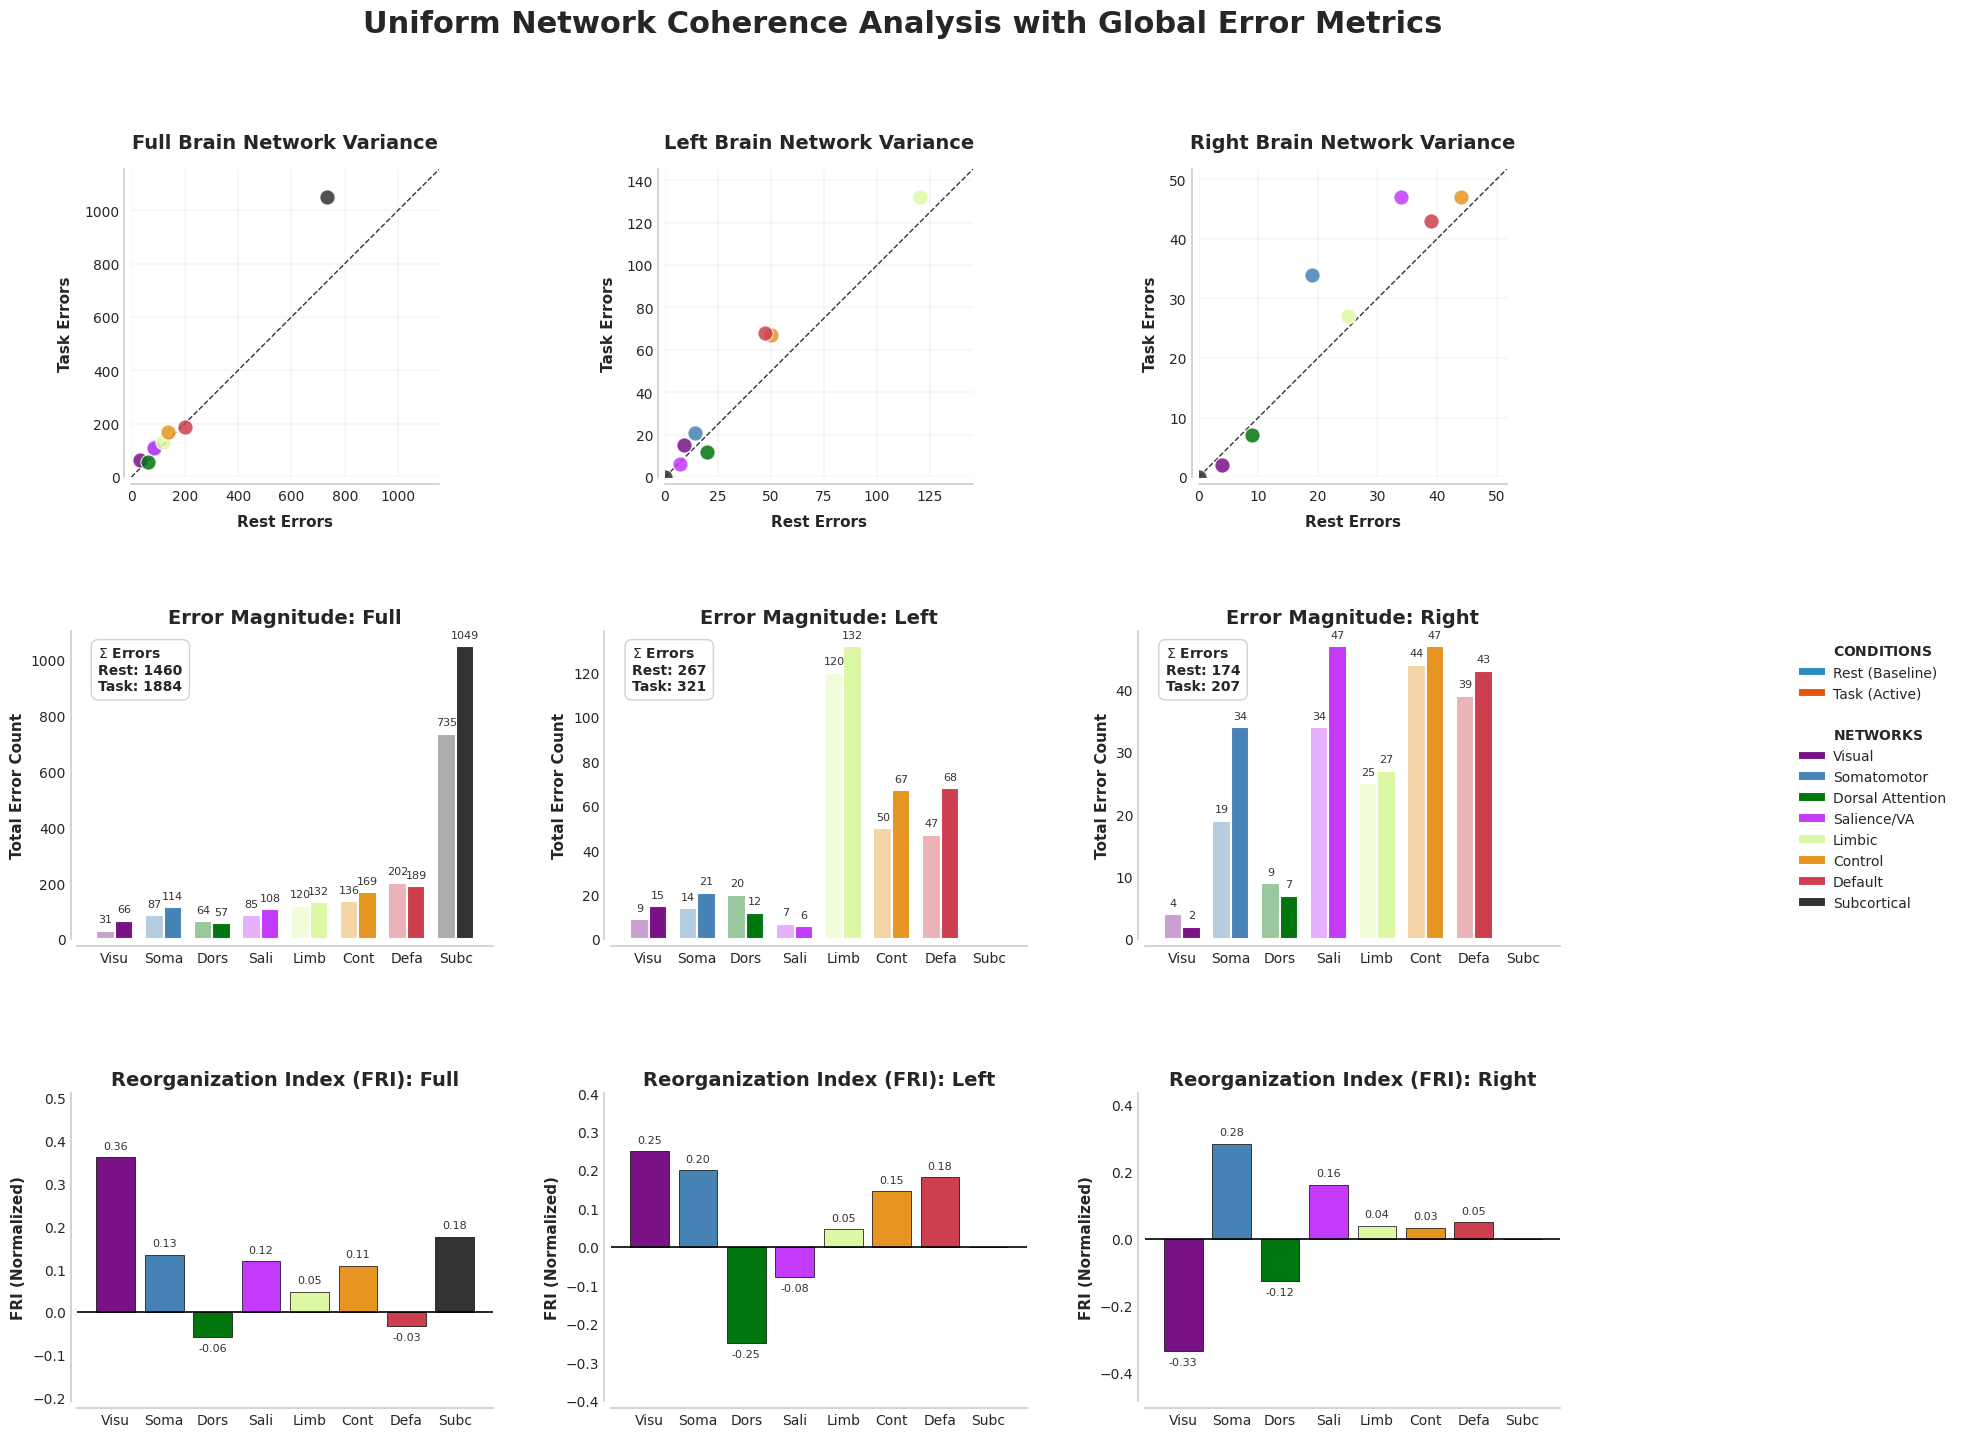

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

# ============================================================================
# STABLE STYLE & FONT SETTINGS
# ============================================================================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Liberation Sans', 'sans-serif'],
    'pdf.fonttype': 42,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'axes.titlesize': 14,
    'axes.labelsize': 11,
})

# Yeo Network Colors
YEO_COLORS = {
    'Visual': '#781286', 'Somatomotor': '#4682B4', 'Dorsal Attention': '#00760E', 
    'Salience/Ventral Attention': '#C43AFA', 'Limbic': '#DCF8A4', 
    'Control': '#E69422', 'Default': '#CD3E4E', 'Subcortical': '#333333'
}

def get_intensity_color(color_hex, amount=0.4):
    """Mixes a network color with white for Rest intensity shading."""
    c = mcolors.to_rgb(color_hex)
    return [(1 - amount) + amount * x for x in c]

def create_publication_figure(cm_rest, cm_task, region_info, networks):
    fig = plt.figure(figsize=(22, 16))
    # GS with 4th column for legend
    gs = fig.add_gridspec(3, 4, width_ratios=[1, 1, 1, 0.25], wspace=0.35, hspace=0.5)
    hemispheres = ['Full', 'Left', 'Right']
    
    for row in range(3):
        for col, hemi in enumerate(hemispheres):
            ax = fig.add_subplot(gs[row, col])
            hemi_code = None if hemi == 'Full' else hemi[0]
            
            # --- ROW 1: SCATTER ---
            if row == 0:
                create_within_network_scatter_plot(cm_rest, cm_task, region_info, networks, hemi, ax, show_legend=False)
                ax.set_title(f'{hemi} Brain Network Variance', pad=15)
                
            # --- ROW 2: MAGNITUDE (Total Error Box in Top-Left) ---
            elif row == 1:
                r_errs = extract_true_within_network_errors(cm_rest, region_info, networks, hemi_code)
                t_errs = extract_true_within_network_errors(cm_task, region_info, networks, hemi_code)
                
                # Global hemisphere statistics
                total_rest = sum(r_errs.values())
                total_task = sum(t_errs.values())
                
                x = np.arange(len(networks))
                width = 0.38
                for i, net in enumerate(networks):
                    base_color = YEO_COLORS.get(net, '#999999')
                    ax.bar(x[i] - width/2, r_errs[net], width, color=get_intensity_color(base_color, 0.4))
                    ax.bar(x[i] + width/2, t_errs[net], width, color=base_color)
                
                # MOVED: Error count box to top-left
                stats_box = f"$\Sigma$ Errors\nRest: {int(total_rest)}\nTask: {int(total_task)}"
                ax.text(0.05, 0.95, stats_box, transform=ax.transAxes, fontsize=10, fontweight='bold',
                        verticalalignment='top', horizontalalignment='left',
                        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#CCCCCC', linewidth=1))
                
                ax.set_title(f'Error Magnitude: {hemi}')
                ax.set_xticks(x)
                ax.set_xticklabels([n[:4] for n in networks], rotation=30, ha='right')
                ax.set_ylabel('Total Error Count')
                ax.grid(False)
                add_bar_labels(ax)
                sns.despine(ax=ax, offset=5)

            # --- ROW 3: REORGANIZATION INDEX ---
            elif row == 2:
                r_e = extract_true_within_network_errors(cm_rest, region_info, networks, hemi_code)
                t_e = extract_true_within_network_errors(cm_task, region_info, networks, hemi_code)
                
                fri_vals = []
                for i, net in enumerate(networks):
                    denom = (t_e[net] + r_e[net])
                    val = (t_e[net] - r_e[net]) / denom if denom > 0 else 0
                    fri_vals.append(val)
                    ax.bar(i, val, color=YEO_COLORS.get(net, '#999999'), edgecolor='black', linewidth=0.5)
                
                ax.axhline(0, color='black', linewidth=1.2, zorder=3)
                ax.set_title(f'Reorganization Index (FRI): {hemi}')
                ax.set_xticks(range(len(networks)))
                ax.set_xticklabels([n[:4] for n in networks], rotation=30, ha='right')
                ax.set_ylabel('FRI (Normalized)')
                ax.set_ylim(min(fri_vals)-0.15, max(fri_vals)+0.15)
                ax.grid(False)
                add_bar_labels(ax)
                sns.despine(ax=ax, offset=5)

    fig.suptitle('Uniform Network Coherence Analysis with Global Error Metrics', 
                 fontsize=22, fontweight='bold', y=0.98)
    create_master_legend(fig, networks)
    return fig

# Run and save
fig = create_publication_figure(confusion_matrix_cv_full, confusion_matrix_task_full, region_info_full, networks_list)
plt.savefig('Network_Dynamics_Final_v2.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import plotly.express as px
import pandas as pd
import numpy as np

def plot_top_error_hubs(matrices, region_info, model_label='Full'):
    """Identifies and visualizes the top 20 regions with the largest change in error rates."""
    
    def get_error_df(cm, info):
        # Calculate recall-based error per region
        row_sums = cm.sum(axis=1)
        # Handle cases where a region might have zero samples to avoid division by zero
        error_rates = np.divide(
            (row_sums - np.diag(cm)), 
            row_sums, 
            out=np.zeros_like(row_sums, dtype=float), 
            where=row_sums != 0
        )
        return pd.DataFrame({
            'Region': info['region_name'],
            'Network': info['major_network'],
            'Error_Rate': error_rates
        })

    # 1. Extract error rates for the specific model
    df_rest = get_error_df(matrices[f'{model_label.lower()}_rest'], region_info)
    df_task = get_error_df(matrices[f'{model_label.lower()}_task'], region_info)

    # 2. Calculate State-Dependent Stability Change (Delta)
    df_importance = df_rest.copy()
    df_importance['Stability_Change'] = df_task['Error_Rate'] - df_rest['Error_Rate']
    
    # Sort by absolute magnitude of change
    df_top = df_importance.sort_values(by='Stability_Change', key=abs, ascending=False).head(20)

    # 3. Create Research-Grade Horizontal Bar Chart
    fig = px.bar(
        df_top,
        x='Stability_Change',
        y='Region',
        color='Network',
        orientation='h',
        title=f"<b>Top 20 Anatomical Hubs: Stability Shift ({model_label})</b>",
        labels={'Stability_Change': 'Δ Error Rate (Task - Rest)'},
        # Use a qualitative palette consistent with brain network standards
        color_discrete_sequence=px.colors.qualitative.Prism 
    )

    fig.update_layout(
        template="plotly_white",
        # Sort regions so the most impacted are at the top
        yaxis={'categoryorder':'total ascending'}, 
        paper_bgcolor='white',
        plot_bgcolor='rgba(245, 245, 245, 0.5)', # Subtle light-grey plot area
        font=dict(family="Arial", size=12),
        margin=dict(l=250, r=50, t=80, b=50),
        showlegend=True,
        legend=dict(title="Functional Network", orientation="h", y=-0.2, x=0.5, xanchor="center")
    )
    
    # Add a zero-line to distinguish between increased and decreased stability
    fig.add_vline(x=0, line_width=2, line_dash="dash", line_color="black")
    
    return fig

# --- INITIALIZE DATA DICTIONARY TO FIX NAMEERROR ---
# Replace these with your actual variables from previous steps
matrices_dict = {
    'full_rest': confusion_matrix_cv_full,
    'full_task': confusion_matrix_task_full,
    'lh_rest': confusion_matrix_cv_lh,
    'lh_task': confusion_matrix_task_lh,
    'rh_rest': confusion_matrix_cv_rh,
    'rh_task': confusion_matrix_task_rh
}

# --- EXECUTE ---
fig_importance = plot_top_error_hubs(matrices_dict, region_info_full, model_label='Full')
fig_importance.show()

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

def get_top_confused_flow(cm, info, top_n=10):
    """
    Identifies top N regions with highest error rates and extracts targets.
    """
    # 1. Convert to float to avoid UFuncTypeError
    row_sums = cm.sum(axis=1).astype(float)
    err_cm = cm.copy().astype(float)
    np.fill_diagonal(err_cm, 0)
    
    region_errors = err_cm.sum(axis=1)
    
    # Corrected division: explicitly provide float64 output array
    error_rates = np.divide(
        region_errors, 
        row_sums, 
        out=np.zeros_like(row_sums, dtype=float), 
        where=row_sums != 0
    )
    
    # 2. Identify Top N most confused regions
    top_indices = np.argsort(error_rates)[-top_n:]
    
    sources, targets, values, labels = [], [], [], []
    region_names = info['region_name'].values
    network_names = info['major_network'].values
    
    # 3. Build Sankey Structure
    for idx in top_indices:
        actual_name = f"{region_names[idx]} ({network_names[idx]})"
        if actual_name not in labels:
            labels.append(actual_name)
        
        # Find top 3 confusion targets for this region
        confusion_row = err_cm[idx, :]
        target_indices = np.argsort(confusion_row)[-3:]
        
        for t_idx in target_indices:
            if confusion_row[t_idx] > 0:
                target_name = f"Pred: {region_names[t_idx]}"
                if target_name not in labels:
                    labels.append(target_name)
                
                sources.append(labels.index(actual_name))
                targets.append(labels.index(target_name))
                values.append(confusion_row[t_idx])
                
    return labels, sources, targets, values

def plot_confusion_sankey(matrices, infos, strategies):
    """Generates Sankey diagrams for top confused regions across strategies."""
    for model_key, display_name in strategies:
        cm = matrices[f'{model_key}_task']
        info = infos[model_key]
        
        labels, sources, targets, values = get_top_confused_flow(cm, info)
        
        fig = go.Figure(data=[go.Sankey(
            node=dict(
                pad=15, thickness=20,
                line=dict(color="black", width=0.5),
                label=labels,
                color="rgba(31, 119, 180, 0.8)"
            ),
            link=dict(
                source=sources, target=targets, value=values,
                color="rgba(200, 200, 200, 0.3)"
            )
        )])

        fig.update_layout(
            title=dict(
                text=f"<b>Error Flow: Top 10 Confused Regions ({display_name})</b>",
                x=0.5, font=dict(size=16)
            ),
            font_size=10, width=1100, height=700,
            paper_bgcolor='white'
        )
        fig.show()

# --- Execution ---
strategies_to_analyze = [('full', 'Full Brain'), ('lh', 'Left Hemisphere'), ('rh', 'Right Hemisphere')]
plot_confusion_sankey(matrices_dict, infos_dict, strategies_to_analyze)

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import pandas as pd
import plotly.express as px

def plot_9_subplot_anatomical_hubs(matrices, region_infos):
    # 1. Setup Subplot Grid (3 Rows, 3 Columns)
    # Rows: Rest, Task, Difference (Task - Rest)
    fig = make_subplots(
        rows=3, cols=3,
        subplot_titles=(
            "Full: Rest", "LH: Rest", "RH: Rest",
            "Full: Task", "LH: Task", "RH: Task",
            "Full: Δ (Task-Rest)", "LH: Δ (Task-Rest)", "RH: Δ (Task-Rest)"
        ),
        horizontal_spacing=0.07,
        vertical_spacing=0.1,
        shared_yaxes=False # Difference scale will be different from absolute counts
    )

    strategies = [('full', 'Full Brain'), ('lh', 'Left Hemisphere'), ('rh', 'Right Hemisphere')]
    
    networks = sorted(region_infos['full']['major_network'].unique())
    colors = px.colors.qualitative.Safe
    color_map = {net: colors[i % len(colors)] for i, net in enumerate(networks)}

    # Global max for rows 1 & 2 (Abs counts)
    max_abs = 0
    # Global max for row 3 (Difference)
    max_diff = 0

    # 2. Pre-calculate scales
    for model_key, _ in strategies:
        # Rest and Task
        r_cm = matrices[f'{model_key}_rest'].astype(float)
        t_cm = matrices[f'{model_key}_task'].astype(float)
        np.fill_diagonal(r_cm, 0); np.fill_diagonal(t_cm, 0)
        
        r_err = r_cm.sum(axis=1)
        t_err = t_cm.sum(axis=1)
        d_err = t_err - r_err
        
        max_abs = max(max_abs, r_err.max(), t_err.max())
        max_diff = max(max_diff, d_err.max())

    # 3. Populate the Grid
    for col_idx, (model_key, _) in enumerate(strategies, start=1):
        info = region_infos[model_key]
        r_cm = matrices[f'{model_key}_rest'].astype(float)
        t_cm = matrices[f'{model_key}_task'].astype(float)
        np.fill_diagonal(r_cm, 0); np.fill_diagonal(t_cm, 0)
        
        r_err = r_cm.sum(axis=1)
        t_err = t_cm.sum(axis=1)
        d_err = t_err - r_err # The "Task Error Plot" (Change)

        state_data = [
            (r_err, 1, max_abs, "Rest"),
            (t_err, 2, max_abs, "Task"),
            (d_err, 3, max_diff, "Difference")
        ]

        for err_vals, row_idx, scale_ref, label in state_data:
            df_plot = pd.DataFrame({
                'Region': info['region_name'],
                'Network': info['major_network'],
                'Error_Count': err_vals,
                'X_Pos': np.arange(len(info))
            })

            for net in networks:
                net_df = df_plot[df_plot['Network'] == net]
                if net_df.empty: continue
                
                # Use absolute value for bubble size in the difference plot 
                # (in case some errors decreased, though unlikely in this dataset)
                bubble_size = np.abs(net_df['Error_Count'])
                
                fig.add_trace(
                    go.Scatter(
                        x=net_df['X_Pos'],
                        y=net_df['Error_Count'],
                        mode='markers',
                        name=net,
                        marker=dict(
                            size=bubble_size,
                            sizemode='area',
                            sizeref=2. * scale_ref / (30.**2),
                            sizemin=2,
                            color=color_map[net],
                            line=dict(width=0.4, color='white')
                        ),
                        text=net_df['Region'],
                        hovertemplate="<b>%{text}</b><br>Errors: %{y}<extra></extra>",
                        legendgroup=net,
                        showlegend=(row_idx == 1 and col_idx == 1) 
                    ),
                    row=row_idx, col=col_idx
                )

    # 4. Refine Layout
    fig.update_layout(
        title=dict(
            text="9-Subplot Anatomical Error Analysis: Strategy vs. State Comparison",
            x=0.5, font=dict(size=22)
        ),
        height=1300, width=1700,
        template="plotly_white",
        legend=dict(title="Functional Network", orientation="h", y=-0.05, x=0.5, xanchor="center"),
        paper_bgcolor='white'
    )

    # Global Axis Formatting
    fig.update_xaxes(showticklabels=False, title="Anatomical Axis")
    fig.update_yaxes(title_text="Abs. Errors", row=1, col=1)
    fig.update_yaxes(title_text="Abs. Errors", row=2, col=1)
    fig.update_yaxes(title_text="Δ Errors (T-R)", row=3, col=1)
    
    # Set uniform ranges for absolute rows vs difference row
    fig.update_yaxes(range=[-5, max_abs * 1.1], row=1); fig.update_yaxes(range=[-5, max_abs * 1.1], row=2)
    fig.update_yaxes(range=[min(0, d_err.min()) - 5, max_diff * 1.1], row=3)

    return fig

# --- Execution ---
fig_9_hubs = plot_9_subplot_anatomical_hubs(matrices_dict, infos_dict)
fig_9_hubs.show()